# Representation of signals & inverse problems - G1-G2

## Lab 1: Introduction to time-frequency analysis

## Guidelines (read carefully before starting)

**Objective**: This practical session consists in a series of 6 short exercises introducting the time-frequency analysis of sounds (acoustic signals).

**Guidelines**: after retrieving the resources for the lab on moodle:

- place the .zip archive in a local folder (Computer -> Documents/Python/);
- unzip the archive .zip;
- rename the folder with the convention lab1_Name1_Name2
- duplicate the notebook file and rename it lab1_Name1_Name2.ipynb;
- [**optional, possibly needed if working from Centrale's machines**]
    - create a `rsp` conda environment from the provided `requirement.txt` file
    ```bash
    conda create --name=rsp --file=requirement.txt
    conda activate rsp
    conda deactivate rsp # to deactivate the conda environment
    # do not forget to deactivate the environment if needed
    # you can remove the environment once you are done
    conda env remove --name=rsp
    ```
    - launch jupyter notebook (the python environment will be the one from the conda environment `rsp`)
- at the end of the session, do not forget to transfer your work to your own network space if you are working on a machine from the school (do not leave your work on the C: drive).
- if needed, an excellent tutorial on the use of Python for scientific computing can be found in the Scipy lecture notes.

**Remark:** some of the Python modules used in this lab session and in the provided module `module_TDS.py` are:

- the `numpy.fft` package, providing implementation of the standard Fourier transforms and related tools: https://docs.scipy.org/doc/numpy/reference/routines.fft.html
- the `scipy.signal` package, containing several functions to perform various operations on signals: https://docs.scipy.org/doc/scipy/reference/signal.html#module-scipy.signal

## Configuration

> **About the resources of this folder**
>
> - `sounds/bird.wav` is the bird song of the course, in its short version (16384 samples at $f_s$ = 15000 Hz, i.e. 1.09 s). The cells that assumed a longer signal sampled at 44100 Hz have been adapted.
> - `sounds/glockenspiel_mono.wav`, `sounds/desactive_mono.wav` and `signal_2sinus.mat` are **synthetic substitutes** generated by `../tools/generate_substitute_sounds.py`, the original files being unavailable.
>
> All the answers below have been written from the figures obtained with these files.

In [1]:
# make sure the notebook reloads the module each time we modify it
%load_ext autoreload
%autoreload 2

# Affichage des figures sous les cellules
%matplotlib inline

In [2]:
from module_TDS import *

In [3]:
from scipy.signal import *
from scipy.io.wavfile import *
from scipy.io import *
from numpy.fft import *
from matplotlib.colors import LogNorm  # for Log normalization
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

# Browser-based audio player: portable and independent of a system audio device
from IPython.display import Audio, display

## Contents

1. Section 1: Fourier analysis (spectral analysis)
    - Exercise 1
2. Section 2: Fourier analysis of segments
    - Exercise 2
    - Exercise 3
3. Section 3: Introduction to time-frequency analysis
    - Exercise 4
4. Section 4: Analysis of some signals
    - Exercise 5
    - Exercise 6
5. Appendix: Time-frequency atoms using a Hanning window
    - useful code examples

## Section 1: Fourier analysis (spectral analysis)

### Reading, displaying, listening to a signal

#### Reading

Signals can be represented as 1D vectors, stored as a row or a column vector.

You can access the help of a specific Python function by pressing `Maj+Tab+Tab` when the cursor is on the desired function.

Examples of availables sound signals are (see folder `sounds\` ):

- bird.wav
- glockenspiel_mono.wav
- aleluya.wav
- desactive_mono.wav
- ...

The following instruction reads a signal from a `.wav` file (song of a bird), before we can listen to it or display it. (see the `sounds\` folder for more examples)

In [4]:
fs, x = read("sounds/bird.wav")

`fs` is the sampling frequency. You can check its value before going on.

In [5]:
fs

15000

#### Listen

In [6]:
display(Audio(x, rate=fs))

#### Display

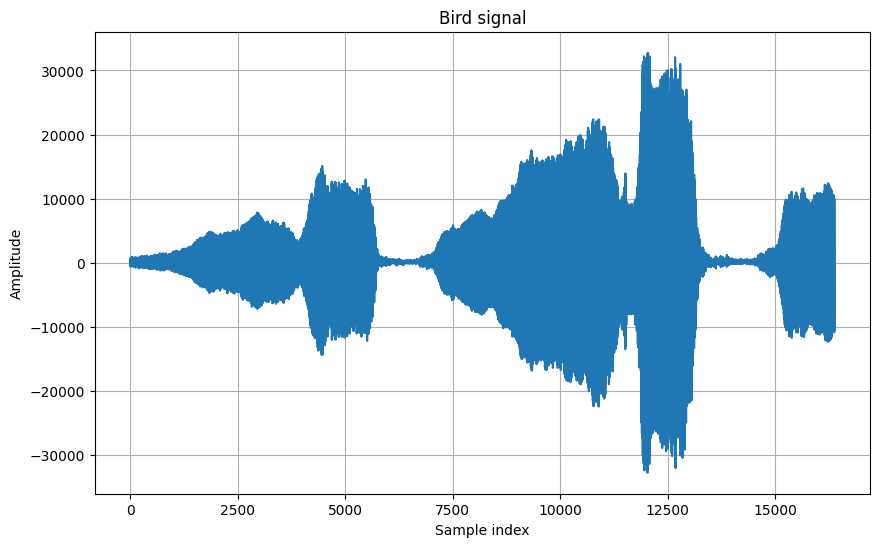

In [7]:
figure(figsize=(10, 6))
plot(x)
grid()
xlabel("Sample index")
ylabel("Amplitude")
title("Bird signal")
show()

Let's have a look at the time-frequency content of this signal, using its spectrogram (see Section 3):

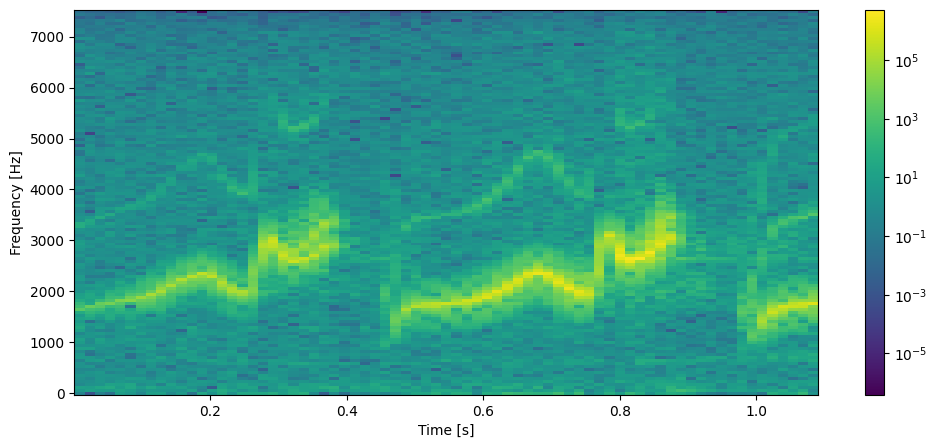

In [8]:
f, t, Sxx = spectrogram(x, fs, nperseg=256)

figure(figsize=(12, 5))
pcolormesh(t, f, Sxx, norm=LogNorm(), shading="auto")
ylabel("Frequency [Hz]")
xlabel("Time [s]")
colorbar()
show()

One can visualize a small segment of the signal (in the time domain) and observe its oscillatory behaviour:

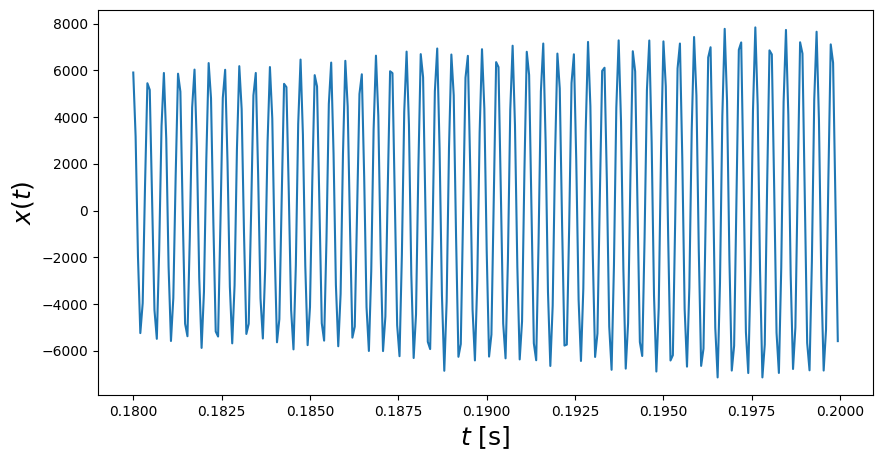

In [9]:
t0 = 0.18  # beginning of the segment [s]
T = 0.02  # duration of the segment [s]

n_start = int(round(fs * t0))  # index of the first sample
n_end = n_start + int(round(fs * T))  # index of the last sample (excluded)

t = np.arange(n_start, n_end) / fs  # time instants of the selected samples

figure(figsize=(10, 5))
plot(t, x[n_start:n_end])
xlabel(r"$t$ [s]", fontsize=18)
ylabel(r"$x(t)$", fontsize=18)
show()

Now consider a limited portion fo the signal, considering only `n` samples:

In [10]:
n = min(2 ** 15, len(x))  # at most 32768 samples (the signal only has 16384 samples)
y = x[:n]

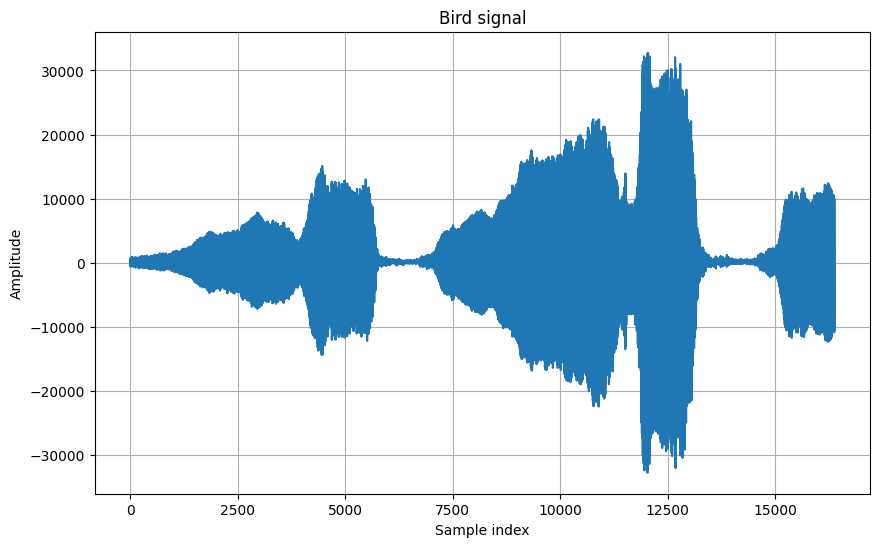

In [11]:
plt.figure(figsize=(10, 6))
plot(y)
grid()
xlabel("Sample index")
ylabel("Amplitude")
title("Bird signal")
show()

## Fourier transform of the signal

One can first compute the discrete Fourier transform of the signal and display its modulus to have an idea about the distribution of its energy in the frequency space (remember that $S_x(\nu) = |X(\nu)|^2$ for continous-time signal of finite energy, with $S_x$ the energy spectral density of $x$).

The frequencies at which the discrete Fourier transform is computed go from $0$ to $(n-1)\frac{f_s}{n}$ (with $n$ the number of signal samples), with a regular frequency step $\frac{f_s}{n}$:

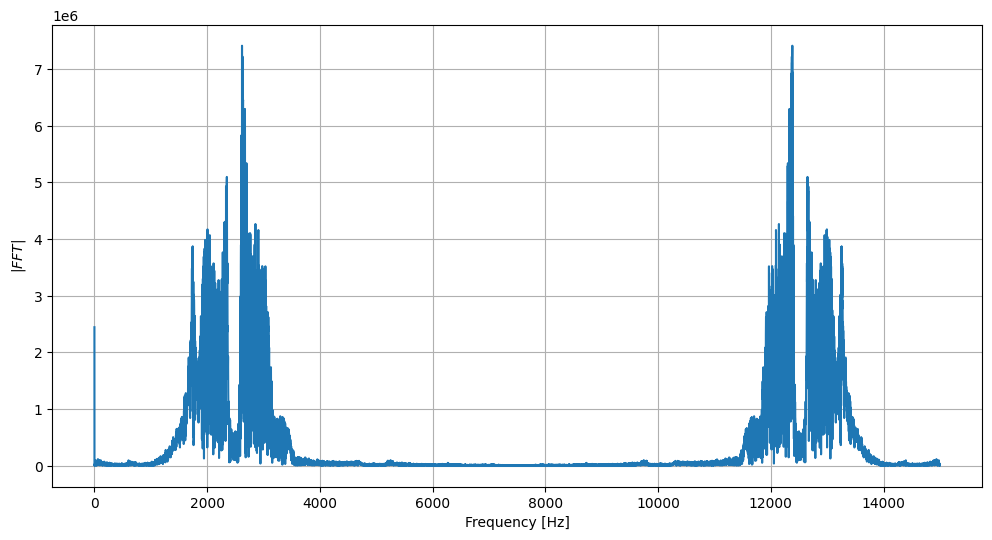

In [12]:
n = min(2 ** 15, len(x))  # we cannot take more samples than available
xn = x[0:n]

Xf = fft(xn)

freq = np.arange(n) * fs / n  # frequencies associated with the FFT coefficients

figure(figsize=(12, 6))
plot(freq, abs(Xf))
xlabel("Frequency [Hz]")
ylabel(r"$| FFT |$")
grid()
show()

For a better readability and to highlight the Hermitian symmetry of the Fourier transform of real signals, the `fftshift` function centers frequencies around 0, between $-\frac{f_s}{2}$ and $(n-1)\frac{f_s}{2n}$.

One can use the `fftfreq` function to automatically access the associated list of frequencies.

*Remark: note that the `fftfreq` function produces frequencies from 0 to $f_s/2$ followed by frequencies from $-f_s/2$ to 0.*

In [13]:
freq = fftfreq(n, d=1.0 / fs)
print(freq[0:3])
print(freq[n // 2 - 2 : n // 2 + 2])  # around the Nyquist frequency fs/2
print(freq[-3:])

[0.         0.91552734 1.83105469]
[ 7498.16894531  7499.08447266 -7500.         -7499.08447266]
[-2.74658203 -1.83105469 -0.91552734]


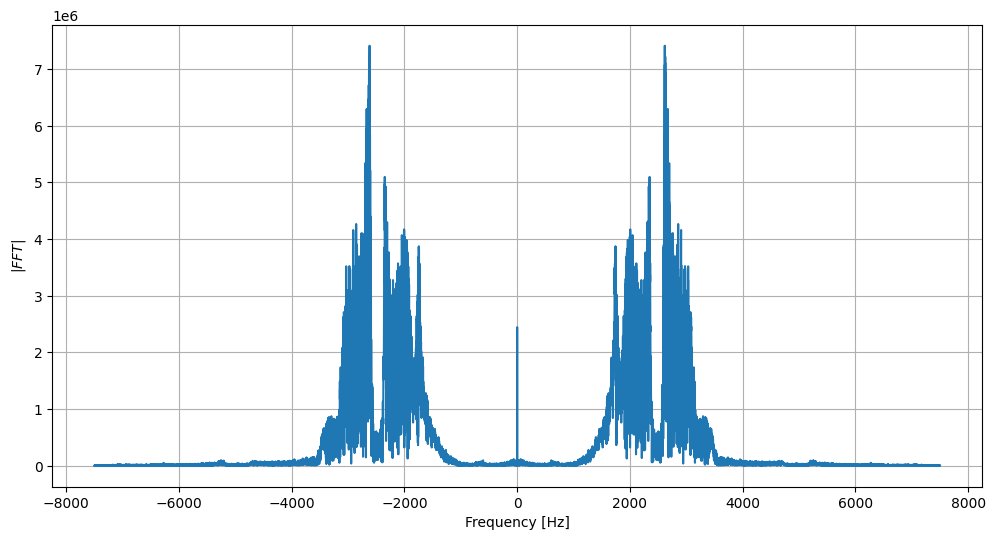

In [14]:
x_f = fftshift(fft(xn))

# freq= arange(-fs/2,fs/2, fs/n) # symmetrical vector of frequencies
freq = fftshift(fftfreq(n, d=1.0 / fs))  # scipy function

figure(figsize=(12, 6))
plot(freq, abs(x_f))
xlabel("Frequency [Hz]")
ylabel(r"$| FFT |$")
grid()
show()

### Exercise 1

1. What is the value of the sampling frequency `fs` used above? What does it correspond to?
2. What are the characteristic frequencies of the bird song studied here?

### Answers to Exercise 1

Sampling frequency fs = 15000 Hz
Number of samples: 16384, duration: 1.092 s
Nyquist frequency fs/2 = 7500 Hz, frequency step fs/n = 0.916 Hz
Frequency of the maximum of |FFT|: 2618 Hz
90% of the energy lies between 1732 Hz and 3027 Hz


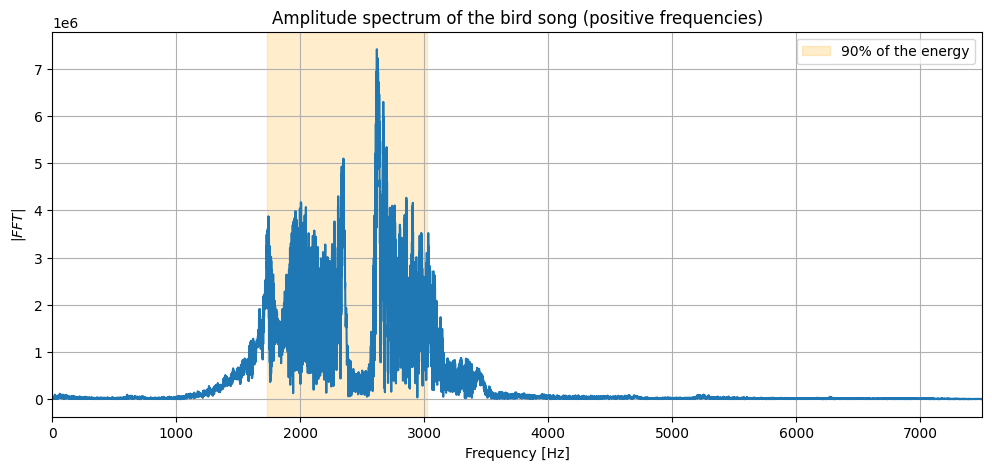

In [15]:
print("Sampling frequency fs = %d Hz" % fs)
print("Number of samples: %d, duration: %.3f s" % (len(x), len(x) / fs))
print("Nyquist frequency fs/2 = %.0f Hz, frequency step fs/n = %.3f Hz" % (fs / 2, fs / n))

# energy spectrum on positive frequencies (the mean value is removed first)
X_pos = np.abs(np.fft.rfft(xn - xn.mean())) ** 2
f_pos = np.fft.rfftfreq(n, d=1.0 / fs)
cumulative = np.cumsum(X_pos) / X_pos.sum()
f_low, f_high = f_pos[np.searchsorted(cumulative, 0.05)], f_pos[np.searchsorted(cumulative, 0.95)]
print("Frequency of the maximum of |FFT|: %.0f Hz" % f_pos[np.argmax(X_pos)])
print("90%% of the energy lies between %.0f Hz and %.0f Hz" % (f_low, f_high))

figure(figsize=(12, 5))
plot(f_pos, np.sqrt(X_pos))
plt.axvspan(f_low, f_high, color="orange", alpha=0.2, label="90% of the energy")
xlim(0, fs / 2)
xlabel("Frequency [Hz]")
ylabel(r"$| FFT |$")
title("Amplitude spectrum of the bird song (positive frequencies)")
legend()
grid()
show()

**1.** The sampling frequency is $f_s$ = **15000 Hz**: the continuous acoustic signal has been measured 15000 times per second, i.e. every $1/f_s \approx 67\ \mu$s. It fixes the largest frequency that can be represented without aliasing, the Nyquist frequency $f_s/2$ = 7500 Hz, which is why the FFT is computed between $-f_s/2$ and $f_s/2$. With $n$ = 16384 samples, the frequency step of the discrete Fourier transform is $f_s/n \approx$ 0.92 Hz.

**2.** The modulus of the FFT is even (Hermitian symmetry of the Fourier transform of a real signal), so only positive frequencies need to be read. The energy of the song is concentrated in a band between about **1700 Hz and 3000 Hz** (90 % of the energy), with a maximum around **2620 Hz**. Above 3500 Hz only a very weak second harmonic remains (less than 0.1 % of the energy, visible on the spectrograms of Exercise 4 between 3500 and 6000 Hz). The spectrum is not a single line but a wide band made of many close peaks: the pitch of the bird changes during the song, and the global Fourier transform mixes all these instantaneous frequencies without telling when each one occurs. The small peak at 0 Hz comes from the non-zero mean value of the recording.

The Fourier transform only gives access to a global information on the frequency content of the signal. A "local" Fourier analysis would be useful to have a more precise description of the sound, such as local amplitude and local frequency variations (local in the temporal domain).

#### Local oscillations of a signal

A sound is usually a locally oscillating, quasi-stationary signal. We illustrate this property by looking more closely at different segments of the signal (in the time domain).

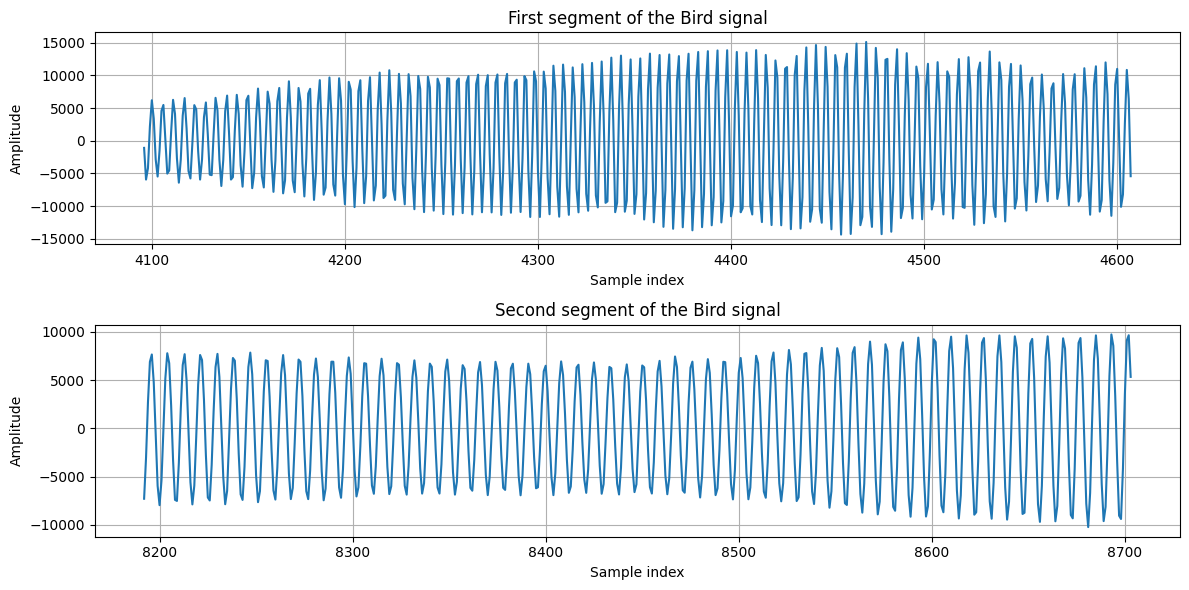

In [16]:
t = np.arange(0, n, 1)  # sample indices
p = 512  # number of samples of a piece of signal

figure(figsize=(12, 6))

sel = int(n / 4) + np.arange(0, p)  # first piece
subplot(211)
plot(t[sel], y[sel])
xlabel("Sample index")
ylabel("Amplitude")
title("First segment of the Bird signal")
grid()

sel = int(n / 2) + np.arange(0, p)  # second piece
subplot(212)
plot(t[sel], y[sel])
xlabel("Sample index")
ylabel("Amplitude")
title("Second segment of the Bird signal")
grid()
tight_layout()
show()

## Section 2: Fourier analysis of segments

**Objective:** this section will guide you to compute the Fourier transform of various segments of the signal (centered around time instants `tk` ), and represent its modulus to illustrate the variations of the local frequency content of the signal across time. Detailed steps are reported at the end of this section.

To this aim, we will consider the Fourier transform (use the `fft` & `fftshift` functions) of segments of the signal `w*x`, where `w` is a window function centered in `tk`. One can use for instance a Gaussian window containing $2N+ 1$ samples, with $N= 400$ and a standard deviation $\sigma = 200$.

**Indication :** to build a Gaussian window, **use the function** `get_window`. Useful code examples are given below, along

**Note:** you should always have $n_{0}> N$, where $n_{0}$ denotes the index of a time instant of interest.

In [17]:
t = np.arange(0, x.size) / fs  # list of times considered

n0 = 10000  # corresponds to instant (n0-1)/fs in time
# t0 = (n0-1)/fs  # instant of interest

N = 400  # half width of the analysing window

L = 2 * N + 1
# number of samples considered per segment

sel = arange(n0 - N, n0 + N + 1, 1)  # sample indices of the selected segment

sigma = 200  # standard deviation of the Gaussian window

gauss_win = get_window(
    ("gaussian", sigma), L
)  # 1/sqrt(2*pi*sigma**2)*exp(-(sel-n0)**2/2/sigma**2);

Displaying the window as a function of the sample index

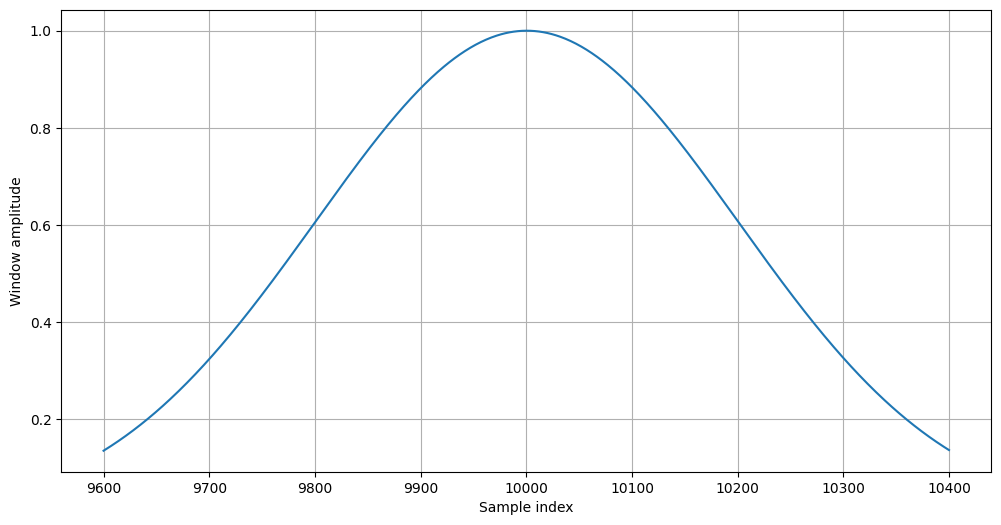

In [18]:
figure(figsize=(12, 6))
plot(sel, gauss_win)
xlabel("Sample index")
ylabel("Window amplitude")
grid()
show()

Displaying the window as a function of time:

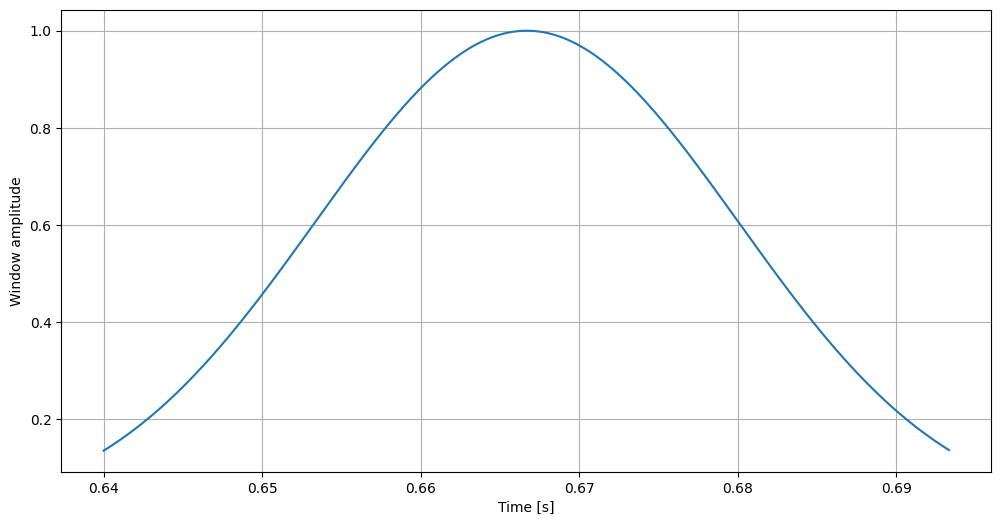

In [19]:
figure(figsize=(12, 6))
plot(t[sel], gauss_win)
xlabel("Time [s]")
ylabel("Window amplitude")
grid()
show()

We extract the signal segment taken for local Fourier analysis, and multiply it by the Gaussian window centered at $n_{0}$ (corresponding to time $t_{0}= (n_{0} -1)/f_{s}$):

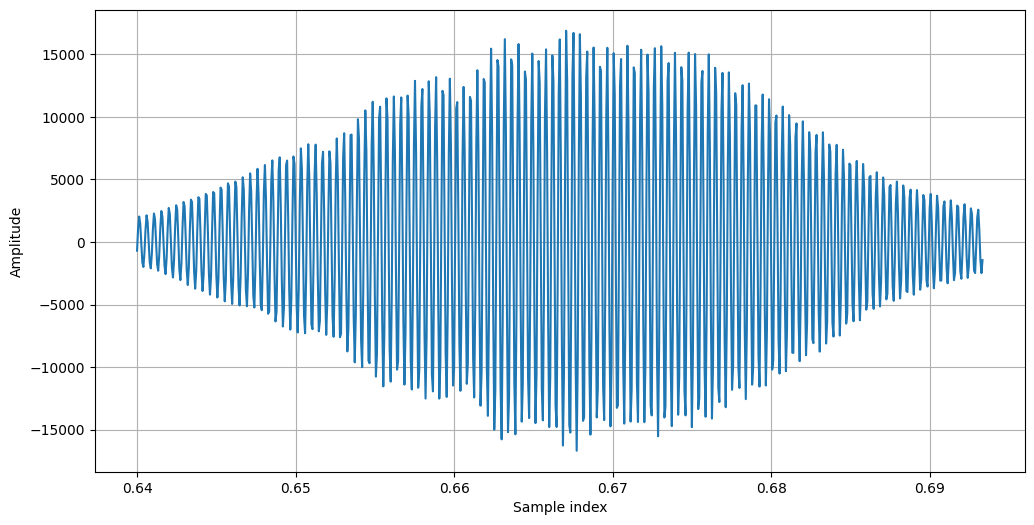

In [20]:
x_segment = gauss_win * xn[sel]

figure(figsize=(12, 6))
plot(t[sel], x_segment)
xlabel("Sample index")
ylabel("Amplitude")
grid()
show()

We compute and display the amplitude spectrum of the segment:

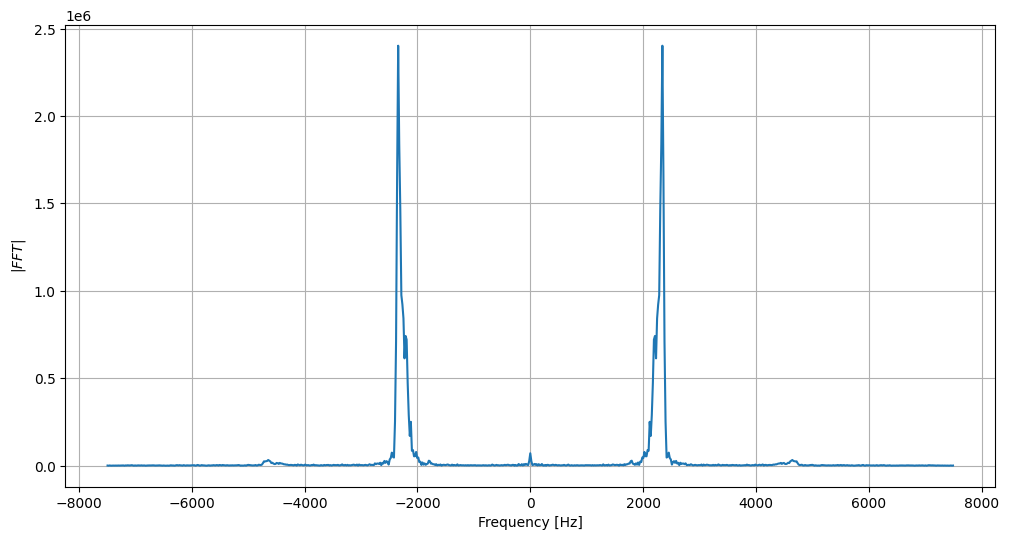

In [21]:
Xf = fftshift(fft(x_segment))
# freq = arange(-fs/2,fs/2,fs/L)  # or see line below:
freq = fftshift(fftfreq(Xf.size, d=1.0 / fs))  # scipy function

figure(figsize=(12, 6))
plot(freq, abs(Xf))
xlabel("Frequency [Hz]")
ylabel(r"$| FFT |$")
grid()
show()

### Exercise 2

1. Compute the Fourier transform of a segment of the signal around different values of `t0` (corresponding to the time sample `n0 = t0*fs` ), for example from `n0` = 1000 to `n0` = 10000 in steps of 1000. For this, we consider the Fourier transform (use `fft` and `fftshift`) of the `x*w` signal where `w` is a regular window function centered on `t0`. For example, use a Gaussian window of width $2N+ 1$ samples with $N= 400$ and $\sigma = 200$.
2. Observe the results obtained and comment.
3. What does the segmented analysis highlight?
4. Display the Gaussian window for different values of $\sigma$ ($\sigma = 50, 100$ et $200$ for instance) as well as its product with the local segment of signal `x[sel]` around some instant.
5. For each value of $\sigma$ (width of the Gaussian window), compute the Fourier transform of the window. Observe & comment.
6. Compute the Fourier transform of a segment of signal around sample $n_{0}= 10000$. Observe and comment.
7. Why do we multiply the segment of signal with a Gaussian (or other) window before computing its Fourier transform ? *You may compare sprectram obtained with/without a Gaussian window, in particular by zooming in the spectral lines to check its detailed shape.*
8. For $\sigma = 200$, write a `for` loop to repeat the previous analysis on one or two segments at various instants $t_{k}$ (associated to samples $n_{k}$ ), for instance from $n_{k}= 10000$ to $n_{k}= 20000$ with a step of $5000$.
9. Represent the sum of all these spectra altogether on one graph. What do you notice in comparison with the global spectrum of the signal $x$? *Indication: you may even extend the result of previous question to a larger set of instants for better evidence; see code below.*

**Remark :** one must always ensure that $n_{0}> N$, where $n_{0}$ denotes the index of a time instant of interest.

### Answers to Exercise 2

**Question 1.** Local spectra for $n_0$ = 1000 to 10000 (step 1000), Gaussian window with $N$ = 400 and $\sigma$ = 200. Only positive frequencies are displayed, the modulus being even.

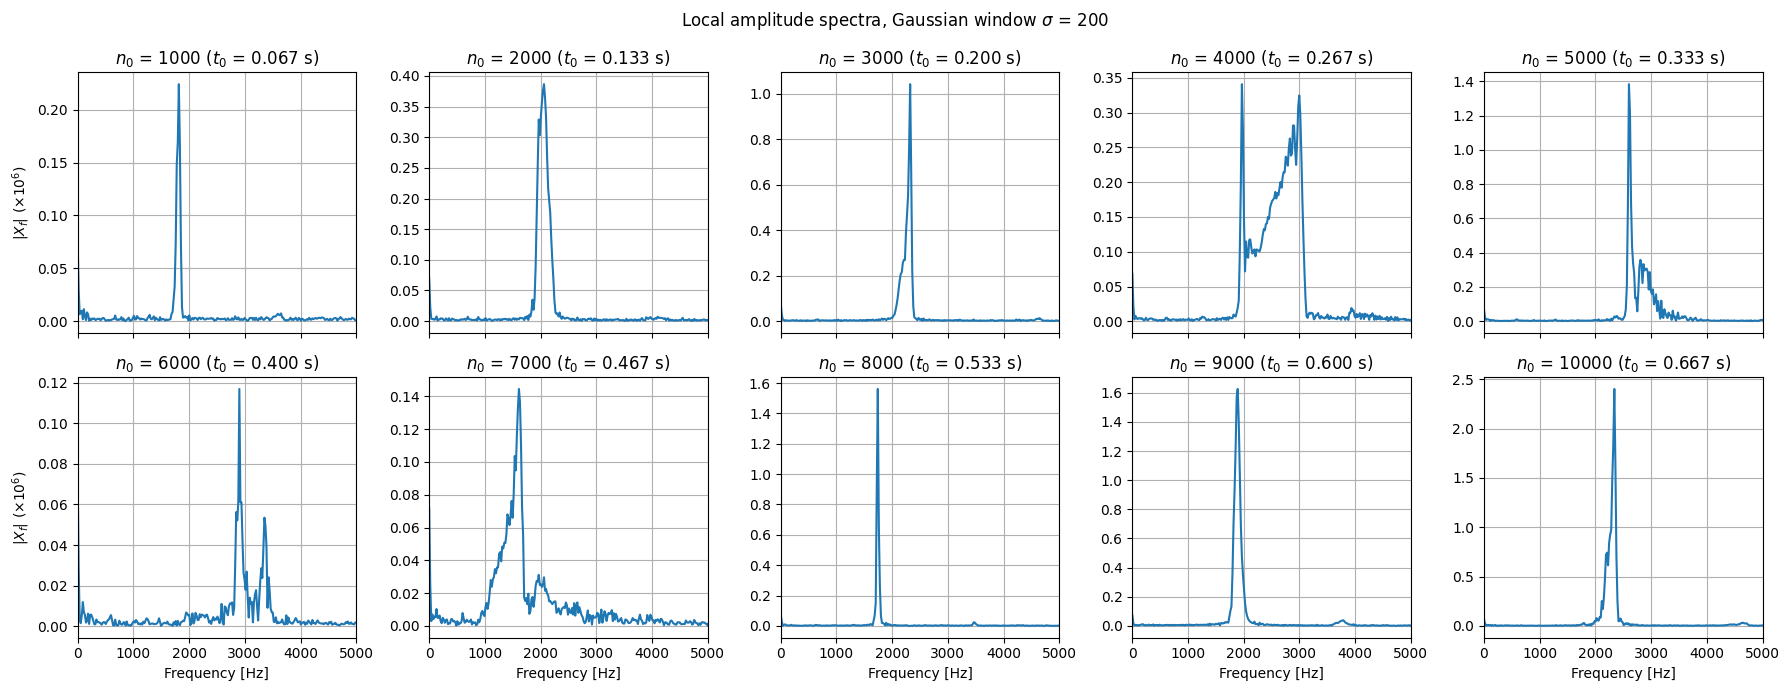

In [22]:
N = 400  # half width of the analysing window
L = 2 * N + 1  # number of samples per segment
sigma = 200  # standard deviation of the Gaussian window
gauss_win = get_window(("gaussian", sigma), L)
freq_seg = fftshift(fftfreq(L, d=1.0 / fs))

n0_list = np.arange(1000, 10001, 1000)
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True)
for ax, n0 in zip(axes.ravel(), n0_list):
    sel = arange(n0 - N, n0 + N + 1, 1)
    Xf = fftshift(fft(gauss_win * xn[sel]))
    ax.plot(freq_seg, abs(Xf) / 1e6)
    ax.set_xlim(0, 5000)
    ax.set_title(r"$n_0$ = %d ($t_0$ = %.3f s)" % (n0, n0 / fs))
    ax.grid()
for ax in axes[1]:
    ax.set_xlabel("Frequency [Hz]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$|X_f|$ ($\times 10^6$)")
fig.suptitle(r"Local amplitude spectra, Gaussian window $\sigma$ = 200")
tight_layout()
show()

**Question 2.** Each local spectrum is much simpler than the global one: most segments contain a **single narrow peak**, whose frequency changes from one instant to the next: about 1800 Hz at $n_0$ = 1000, 2050 Hz at $n_0$ = 2000, 2300 Hz at $n_0$ = 3000, 2600 Hz at $n_0$ = 5000, 1750 Hz at $n_0$ = 8000, 1900 Hz at $n_0$ = 9000 and 2350 Hz at $n_0$ = 10000. Some segments are more complex: at $n_0$ = 4000 a narrow peak near 1950 Hz is followed by a wide band up to 3000 Hz (the frequency sweeps quickly inside the window, see the jump of the melody around 0.27 s on the spectrograms of Exercise 4), at $n_0$ = 6000 two components appear near 2900 and 3350 Hz, and at $n_0$ = 7000, at the beginning of the second phrase of the song, a peak near 1600 Hz sits on a wide band from 1000 to 2500 Hz. The amplitude also varies a lot from one segment to the other (from about $10^5$ to $2.4 \times 10^6$), following the envelope of the song.

**Question 3.** The segmented analysis shows that the bird song is a **locally quasi-stationary signal with a time-varying frequency**: over 800 samples (53 ms) it is close to a sinusoid, but its instantaneous frequency sweeps the 1700 to 3000 Hz band during the song. The wide band seen in the global spectrum is therefore not made of simultaneous frequencies: it is the superposition of narrow lines occurring at different times. The local analysis gives access to *when* each frequency is present, which the global Fourier transform cannot provide.

**Question 4.** Gaussian windows for $\sigma$ = 50, 100, 200, and their product with the segment centred at $n_0$ = 10000.

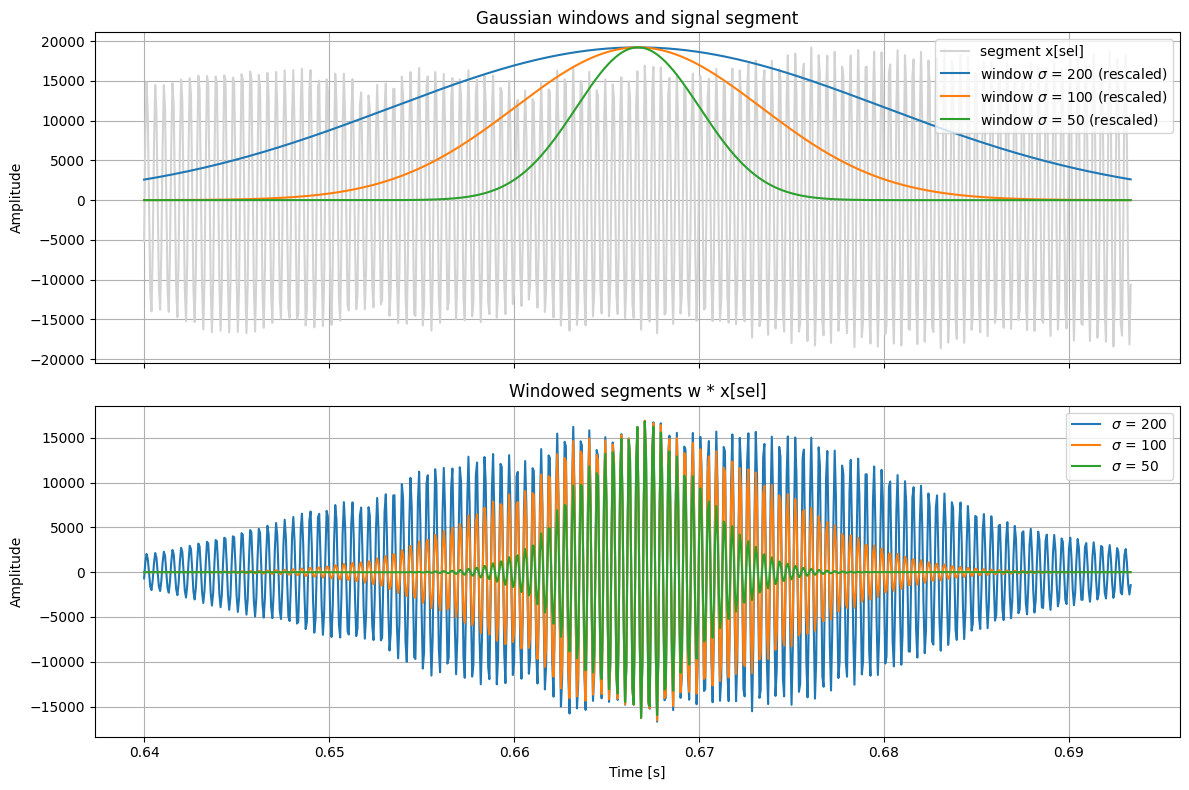

In [23]:
n0 = 10000
sel = arange(n0 - N, n0 + N + 1, 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(sel / fs, xn[sel], color="lightgray", label="segment x[sel]")
for sigma in [200, 100, 50]:
    w = get_window(("gaussian", sigma), L)
    axes[0].plot(sel / fs, w * np.abs(xn[sel]).max(), label=r"window $\sigma$ = %d (rescaled)" % sigma)
    axes[1].plot(sel / fs, w * xn[sel], label=r"$\sigma$ = %d" % sigma)
axes[0].set_title("Gaussian windows and signal segment")
axes[1].set_title("Windowed segments w * x[sel]")
axes[1].set_xlabel("Time [s]")
for ax in axes:
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")
    ax.grid()
tight_layout()
show()

All the windows are centred on $n_0$ and contain $2N+1$ = 801 samples, but their **effective duration** is set by $\sigma$: about $\pm 2\sigma$ samples, i.e. $\pm$ 13 ms for $\sigma$ = 200 and only $\pm$ 3 ms for $\sigma$ = 50. Multiplying by the window keeps the samples close to $t_0$ and progressively cancels the others: with $\sigma$ = 50 only a few periods of the oscillation remain, with $\sigma$ = 200 the windowed segment still contains many periods. Note that for $\sigma$ = 200 the window is not negligible at the edges of the segment (about 14 % of its maximum at $\pm N = \pm 2\sigma$): it is a truncated Gaussian.

**Question 5.** Fourier transform of the windows themselves (zero-padded to 8192 points to see their shape precisely).

sigma =  50: -6 dB width of the main lobe = 109.9 Hz (theory 2.355 fs/(2 pi sigma) = 112.4 Hz)
sigma = 100: -6 dB width of the main lobe =  54.9 Hz (theory 2.355 fs/(2 pi sigma) =  56.2 Hz)
sigma = 200: -6 dB width of the main lobe =  29.3 Hz (theory 2.355 fs/(2 pi sigma) =  28.1 Hz)


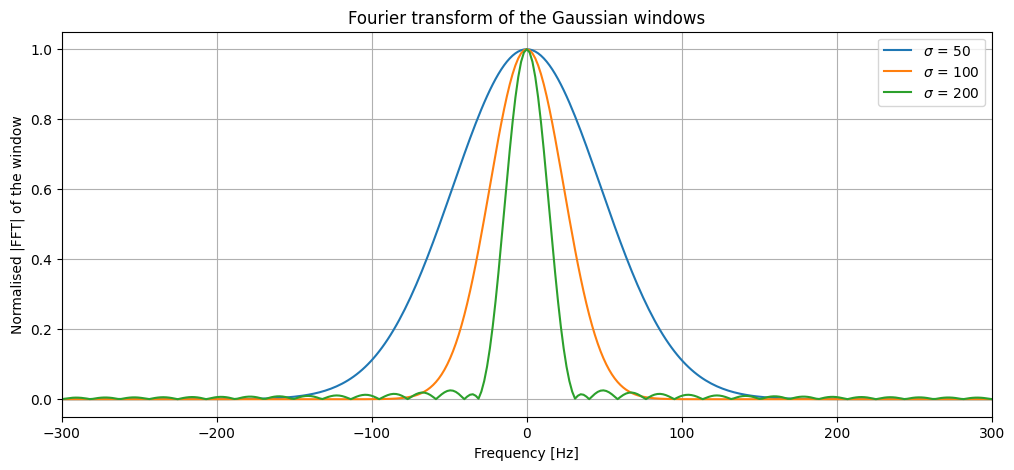

In [24]:
nfft = 8192
freq_w = fftshift(fftfreq(nfft, d=1.0 / fs))

figure(figsize=(12, 5))
for sigma in [50, 100, 200]:
    w = get_window(("gaussian", sigma), L)
    W = abs(fftshift(fft(w, nfft)))
    W = W / W.max()
    half = freq_w[W >= 0.5]
    print("sigma = %3d: -6 dB width of the main lobe = %5.1f Hz (theory 2.355 fs/(2 pi sigma) = %5.1f Hz)"
          % (sigma, half.max() - half.min(), 2.355 * fs / (2 * np.pi * sigma)))
    plot(freq_w, W, label=r"$\sigma$ = %d" % sigma)
xlim(-300, 300)
xlabel("Frequency [Hz]")
ylabel("Normalised |FFT| of the window")
title("Fourier transform of the Gaussian windows")
legend()
grid()
show()

The Fourier transform of a Gaussian window is again a Gaussian: a window of standard deviation $\sigma$ samples ($\sigma/f_s$ seconds) has a transform of standard deviation $\sigma_f = f_s/(2\pi\sigma)$ in frequency. The measured widths confirm it: the main lobe is about **110 Hz wide for $\sigma$ = 50, 55 Hz for $\sigma$ = 100 and 29 Hz for $\sigma$ = 200** (width divided by 2 when $\sigma$ is multiplied by 2). For $\sigma$ = 200, small side lobes appear around the main lobe: they come from the truncation of the Gaussian at $\pm 2\sigma$ mentioned in question 4.

This is the key point of windowed Fourier analysis: the local spectrum is the spectrum of the signal **convolved** with the transform of the window. A short window (small $\sigma$) localises well in time but blurs each spectral line over a wide frequency band; a long window gives thin lines but mixes what happens over a longer duration. The product of the two widths cannot be made arbitrarily small (Gabor-Heisenberg inequality, equality reached for the Gaussian window).

**Question 6.** Fourier transform of the segment around $n_0$ = 10000 ($t_0$ = 0.667 s), Gaussian window $\sigma$ = 200.

Main peak at 2342 Hz


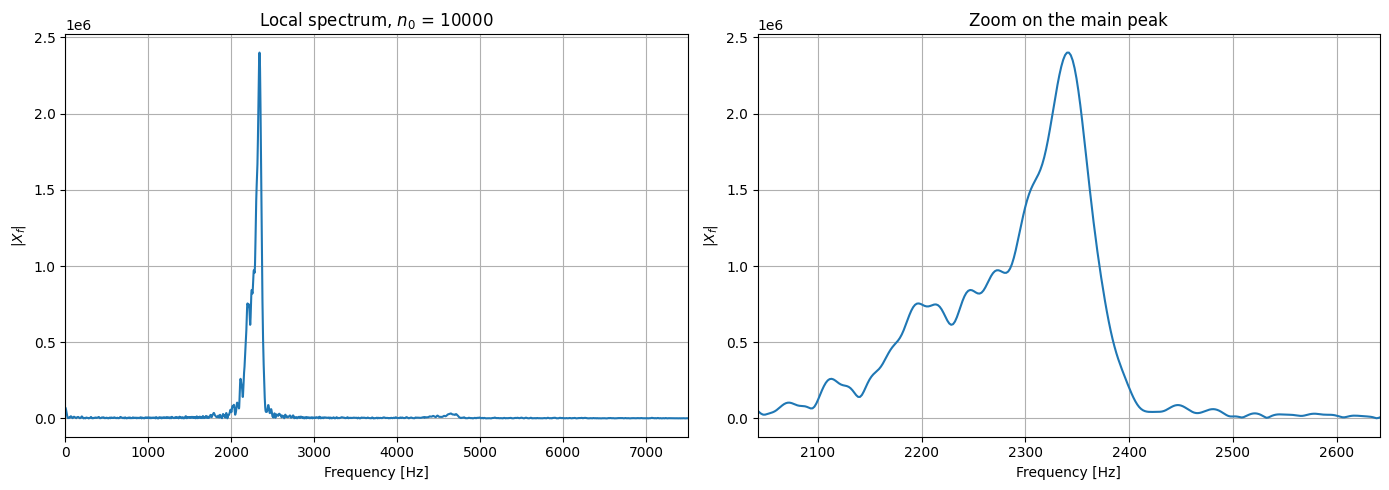

In [25]:
n0 = 10000
sigma = 200
sel = arange(n0 - N, n0 + N + 1, 1)
gauss_win = get_window(("gaussian", sigma), L)
Xf = fftshift(fft(gauss_win * xn[sel], nfft))
k = np.argmax(abs(Xf) * (freq_w > 0))
print("Main peak at %.0f Hz" % freq_w[k])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(freq_w, abs(Xf))
axes[0].set_xlim(0, fs / 2)
axes[0].set_title(r"Local spectrum, $n_0$ = 10000")
axes[1].plot(freq_w, abs(Xf))
axes[1].set_xlim(freq_w[k] - 300, freq_w[k] + 300)
axes[1].set_title("Zoom on the main peak")
for ax in axes:
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(r"$|X_f|$")
    ax.grid()
tight_layout()
show()

Around $t_0$ = 0.667 s the local spectrum is dominated by **one line at about 2340 Hz**. It is not perfectly symmetric: it has a shoulder on its low-frequency side, down to about 2000 Hz, because the pitch of the bird changes during the 53 ms of the window (the melody is descending from 2340 Hz at that moment). A very weak line also appears near 4700 Hz, twice the main frequency: it is the second harmonic of the song, about 100 times weaker (log-scale plot of question 7). Over this short duration the bird therefore emits an almost pure tone, and this line is one of the many lines that make up the wide band of the global spectrum.

**Question 7.** Same segment, with and without the Gaussian window (the rectangular window corresponds to simply cutting the signal).

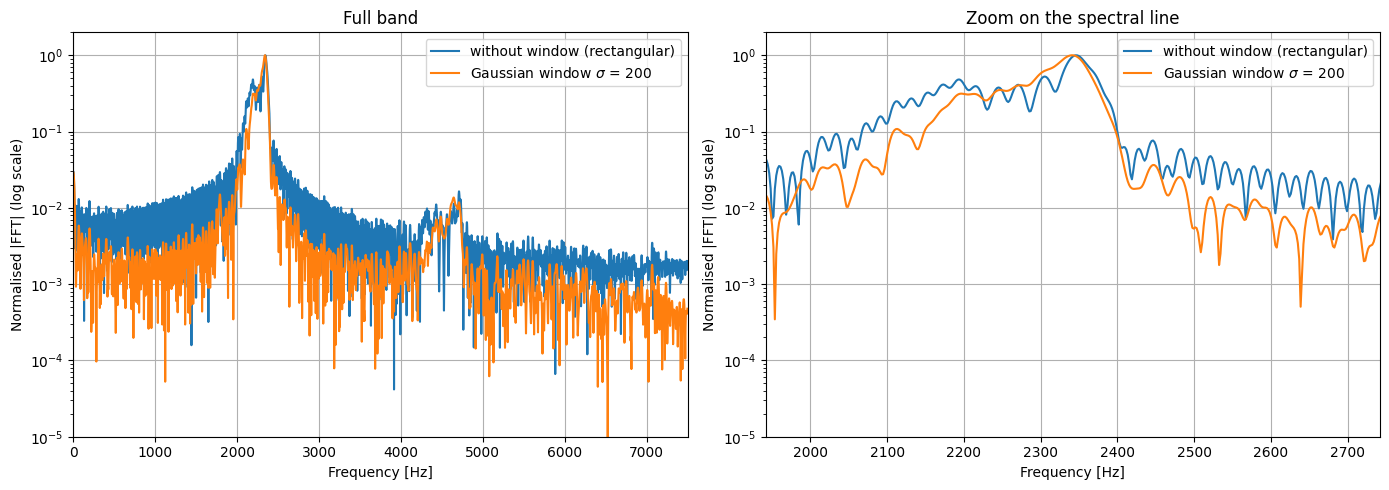

In [26]:
X_rect = fftshift(fft(xn[sel], nfft))  # no window = rectangular window
X_gauss = fftshift(fft(gauss_win * xn[sel], nfft))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, zoom in zip(axes, [(0, fs / 2), (freq_w[k] - 400, freq_w[k] + 400)]):
    ax.semilogy(freq_w, abs(X_rect) / abs(X_rect).max(), label="without window (rectangular)")
    ax.semilogy(freq_w, abs(X_gauss) / abs(X_gauss).max(), label=r"Gaussian window $\sigma$ = 200")
    ax.set_xlim(*zoom)
    ax.set_ylim(1e-5, 2)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Normalised |FFT| (log scale)")
    ax.grid()
    ax.legend()
axes[0].set_title("Full band")
axes[1].set_title("Zoom on the spectral line")
tight_layout()
show()

Without window, the segment is multiplied by a rectangular function, whose Fourier transform is a cardinal sine: its main lobe is narrow ($2 f_s/L \approx$ 37 Hz) but its **side lobes decrease slowly** (first one at -13 dB). Each spectral line is therefore surrounded by oscillating side lobes that spread over the whole band: this is the **spectral leakage** caused by the abrupt truncation of the signal at both ends of the segment. On the log-scale plots, the floor of the rectangular spectrum stays about ten times higher than with the Gaussian window over the whole band, and around the line (zoom) it shows the regular oscillations of the side lobes of the sinc function.

Multiplying by a smooth window that goes to zero at the edges removes these discontinuities: the line is slightly wider, but leakage is strongly reduced, so that weak components (such as the second harmonic near 4700 Hz) are not hidden by the side lobes of strong ones and the local spectrum really describes the signal around $t_0$. The window is not used to remove noise, but to control the shape of the spectral lines.

**Question 8.** Loop over the instants $n_k$ from 10000 to 20000 with a step of 5000. The signal only has 16384 samples: the window centred at $n_k$ = 20000 would go beyond its end, so only the instants whose window fits in the signal are kept.

Instants used: [10000, 15000]


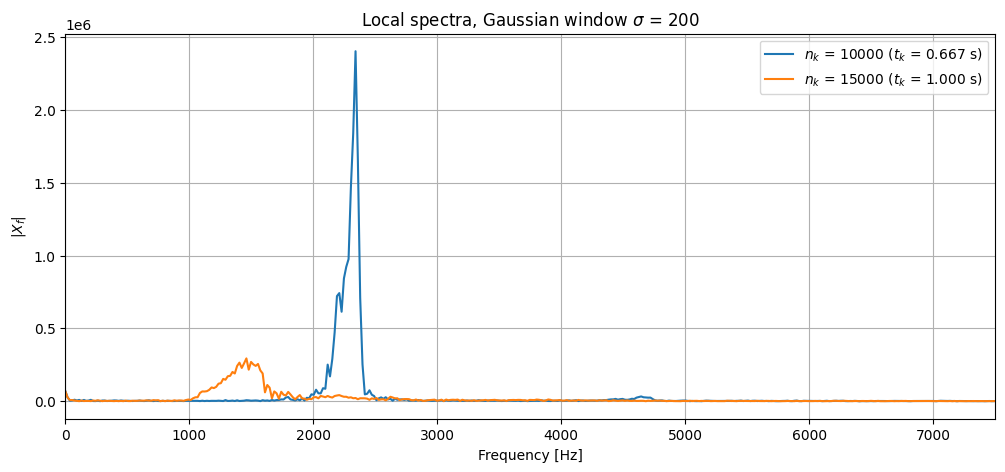

In [27]:
N = 400
L = 2 * N + 1
sigma = 200
gauss_win = get_window(("gaussian", sigma), L)

nk_list = [nk for nk in range(10000, 20001, 5000) if N <= nk <= len(xn) - N - 1]
print("Instants used:", nk_list)

figure(figsize=(12, 5))
for nk in nk_list:
    sel = arange(nk - N, nk + N + 1, 1)
    Xf = fftshift(fft(gauss_win * xn[sel]))
    plot(freq_seg, abs(Xf), label=r"$n_k$ = %d ($t_k$ = %.3f s)" % (nk, nk / fs))
xlim(0, fs / 2)
xlabel("Frequency [Hz]")
ylabel(r"$|X_f|$")
title(r"Local spectra, Gaussian window $\sigma$ = 200")
legend()
grid()
show()

At $n_k$ = 10000 ($t_k$ = 0.667 s) the song is a line at about 2340 Hz; at $n_k$ = 15000 ($t_k$ = 1.0 s), after the end of the song, the local spectrum is about ten times weaker and made of lower components around 1300 to 1450 Hz. The same analysis at two instants gives two very different spectra, which again shows that the frequency content of the song evolves in time.

**Question 9.** Sum of the local energy spectra $|X_f|^2$ over many instants (every 100 samples, windows fully inside the signal), compared with the global energy spectrum. Both curves are normalised by their maximum.

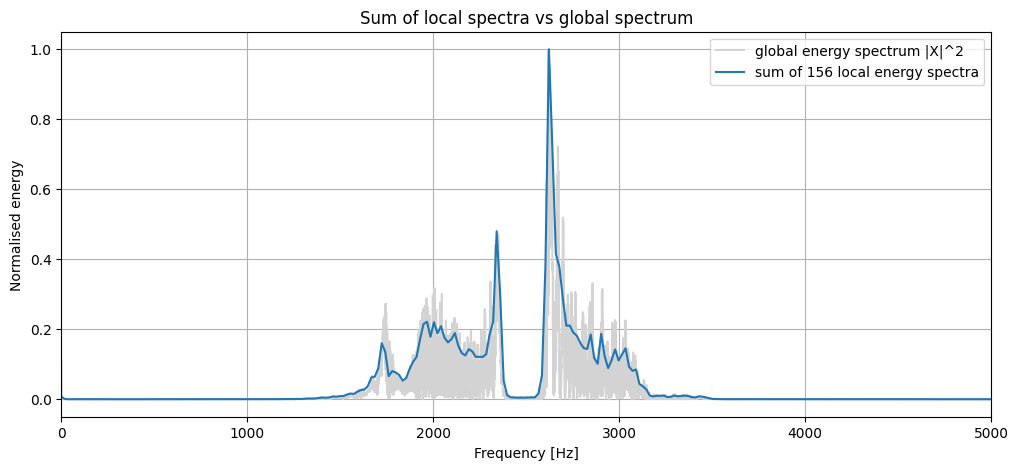

In [28]:
step = 100
nk_all = np.arange(N, len(xn) - N, step)
S_sum = np.zeros(L)
for nk in nk_all:
    sel = arange(nk - N, nk + N + 1, 1)
    S_sum += abs(fftshift(fft(gauss_win * xn[sel]))) ** 2

X_global = abs(fftshift(fft(xn))) ** 2
freq_global = fftshift(fftfreq(xn.size, d=1.0 / fs))

figure(figsize=(12, 5))
plot(freq_global, X_global / X_global.max(), color="lightgray", label="global energy spectrum |X|^2")
plot(freq_seg, S_sum / S_sum.max(), label="sum of %d local energy spectra" % nk_all.size)
xlim(0, 5000)
xlabel("Frequency [Hz]")
ylabel("Normalised energy")
title("Sum of local spectra vs global spectrum")
legend()
grid()
show()

The sum of the local energy spectra has the **same overall shape as the global spectrum**: the same 1700 to 3000 Hz band, with the same main maximum near 2620 Hz, the same secondary maximum near 2340 Hz and the same empty gap between 2400 and 2550 Hz. Summing the local spectra over all the instants loses the time information and gives back an estimate of the global distribution of energy in frequency: this is the frequency marginal of the spectrogram, a consequence of energy conservation (Parseval) for the short-time Fourier transform.

The two curves are not identical, though: the global spectrum is computed with a frequency step of 0.92 Hz and shows many thin peaks, whereas each local spectrum has a resolution of about 30 Hz (question 5), so their sum is a **smoothed** version of the global spectrum. Summing moduli $|X_f|$ or complex values instead of energies would not have this interpretation (phases would interfere).

### A dynamic plot of the Short-Time Fourier Transform

In [29]:
# !!!! DO NOT MODIFY THIS CELL !!!!
from bokeh.layouts import row, column

# t=np.arange(0,xn.size)/fs # list of times considered


def fft_segment(k=1):

    # fs: sampling frequency read from the file
    n0 = k * 500
    N = 200
    L = 2 * N + 1
    # number of samples considered per segment
    sel = arange(n0 - N, n0 + N + 1, 1)  # sample indices of the selected segment
    sigma = 100
    gauss_win = get_window(
        ("gaussian", sigma), L
    )  # 1/sqrt(2*pi*sigma**2)*exp(-(sel-n0)**2/2/sigma**2);

    x_segment = gauss_win * xn[sel]
    Xf = fftshift(fft(x_segment))

    xs = [[(n0 - N) / fs, (n0 - N) / fs], [(n0 + N) / fs, (n0 + N) / fs]]
    M = max(abs(xn))
    ys = [[-M, M]] * 2

    window_line.data_source.data = dict(xs=xs, ys=ys)
    rx.data_source.data = dict(x=t[sel], y=x_segment)
    rX.data_source.data["y"] = abs(Xf)
    push_notebook()


fig_xn = bkfigure(title="x", plot_height=200, plot_width=600)
fig_x = bkfigure(title="x_segment", plot_height=200, plot_width=300)
fig_X = bkfigure(title="| FFT [x_segment] |", plot_height=200, plot_width=300)

n0 = 500
N = 200
L = 2 * N + 1
sel = arange(n0 - N, n0 + N + 1, 1)
sigma = 100
gauss_win = get_window(
    ("gaussian", sigma), L
)  # 1/sqrt(2*pi*sigma**2)*exp(-(sel-n0)**2/2/sigma**2);
x_segment = gauss_win * xn[sel]
Xf = fftshift(fft(x_segment))
freq = fftshift(fftfreq(Xf.size, d=1.0 / fs))
# freq = arange(-fs/2,fs/2,fs/L)

# !!!! DO NOT MODIFY THIS CELL !!!!

In [30]:
# EXECUTE THE PREVIOUS CELL THEN THIS CELL TO START THE INTERACTIVE VISUALIZATION
# plot of the original signal xn
t = np.arange(0, xn.size) / fs  # list of times considered

M = max(abs(xn))
rxn = fig_xn.line(t, xn)  # ,color = "red")
window_line = fig_xn.multi_line(
    xs=[[(n0 - N) / fs, (n0 - N) / fs], [(n0 + N) / fs, (n0 + N) / fs]],
    ys=[[-M, M]] * 2,
    color="firebrick",
    line_width=2,
)
# plots of the segement and its Fourier transform
rx = fig_x.line(t[sel], x_segment)  # ,color = "red")
rX = fig_X.line(freq, abs(Xf))  # ,color = "red")

bkshow(column(children=[fig_xn, row(fig_x, fig_X)]), notebook_handle=True)
k_max = (xn.size - N - 1) // 500  # the window must stay inside the signal
interact(fft_segment, k=(1, k_max));

interactive(children=(IntSlider(value=1, description='k', max=32, min=1), Output()), _dom_classes=('widget-int…

### Exercise 3

1. Move the cursor above to explore the signal in time and frequency
2. Comment on your observations.

### Answers to Exercise 3

The slider moves a Gaussian window ($N$ = 200, $\sigma$ = 100, i.e. about 13 ms) along the signal, and the right panel shows the local spectrum of the selected segment. The song is made of two similar phrases (about 0 to 0.38 s and 0.45 to 0.9 s, see the spectrograms of Exercise 4). When the window lies in one of them, the local spectrum shows one dominant pair of peaks $\pm f$, and moving the slider makes this pair **slide continuously**: it rises from about 1700 Hz to 2300 Hz, comes back to 2000 Hz, then jumps to 3000 Hz at the end of each phrase, where the peak widens and splits into several components. A much weaker pair is visible at twice the frequency (second harmonic). When the window lies in the pause between the phrases (around 0.4 s) or after the end of the song, the whole spectrum collapses to a very low level. The frequency resolution is coarser than in Exercise 2 ($\sigma$ = 100 instead of 200, so the peaks are twice as wide) but the time localisation is better. This interactive view is exactly what the spectrogram of the next section summarises in a single image: time on one axis, frequency on the other, and the modulus of the local Fourier transform as colour.

## Section 3: Introduction to time-frequency analysis

### Short-Time Fourier Transform: spectrogram & reconstruction

In order to follow the evolution of the frequency content of a signal over time, one can use the *Short-Time Fourier Transform (STFT)*. This representation has 2 indices, one for the time instant where the window is centered, and another for the frequencies. In practice, computing the STFT first consists in dividing the time signal into shorter segments, of equal length. A Fourier transform is then computed separately for each of the extracted segments. This reveals the Fourier spectrum of each shorter segment.

The interest of this representation is to gather local Fourier transforms (vertical frequency axis) calculated on regularly spaced time windows (horizontal time axis) so as to deduce the **spectrogram**, a 2D visual heat map. The square of the amplitude of the STFT is interpreted as a time-frequency energy density.

In general, windows overlap in time, which leads to a certain redundancy enhancing the readability of the time-frequency information. This redundant representation can be reversed (*pseudo-inverse*) to reconstruct the original signal. One can show that the energy is preserved from the time to the frequency domain.

The parameters to compute a spectrogram parameters are:

- the shape of the analysis window
- the window size
- the time spacing between 2 successive windows, denoted `spacing` here, which also conditions the amount of overlap between consecutive windows.

The `stft` function is used to calculate the Short-Time Fourier Transform of a given signal, while the `spectrogram` function provides a graphical representation. The vertical axis corresponds to the frequencies (positive only) sampled between $0$ and $\frac{f_s}{2}$, and the horizontal axis to temporal samples.

An example of application is given below:

In [31]:
n = 14000
# length of the extracted vector
fs, x = read("sounds/bird.wav")
y = x[0:n]

display(Audio(y, rate=fs))

In [32]:
fs

15000

Computing the STFT transform of the signal:

In [33]:
width = 512
# window width
spacing = width / 8
# number of samples between 2 successive segments
window = "hann"
# window used

t_stft, f_stft, x_stft = stft(
    x, fs=1.0, window="hann", nperseg=width, noverlap=width - spacing
)

**Indication:** A logarithmic scale is used to display the spectrogram amplitude. In addition, the times and frequencies at which the spectrogram is observed are given by

- `nf, nw = S[0].size, S[1].size`
- `T = n/fs`
- `t_stft = arange(0,nw)*T/spacing`
- `f_stft = arange(0,nf/2)*fs/width`

**Graphical representation of an analysis window**

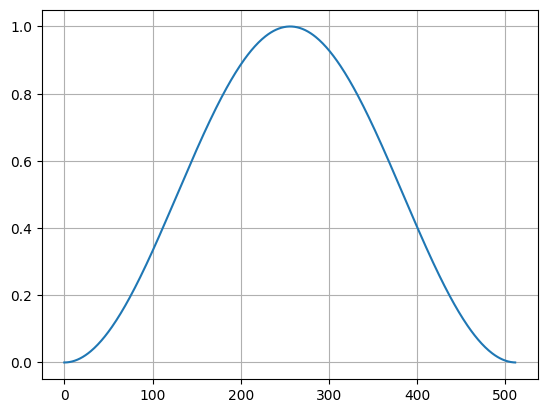

In [34]:
w = hann(M=512)
w = get_window("hann", width)
plot(w)
grid()
show()

**Graphical representation of the spectrogram**: you can either choose the STFT modulus calculated above, or use the `spectrogram` function which calculates the square of its modulus (due to the energy conservation theorem for the STFT).

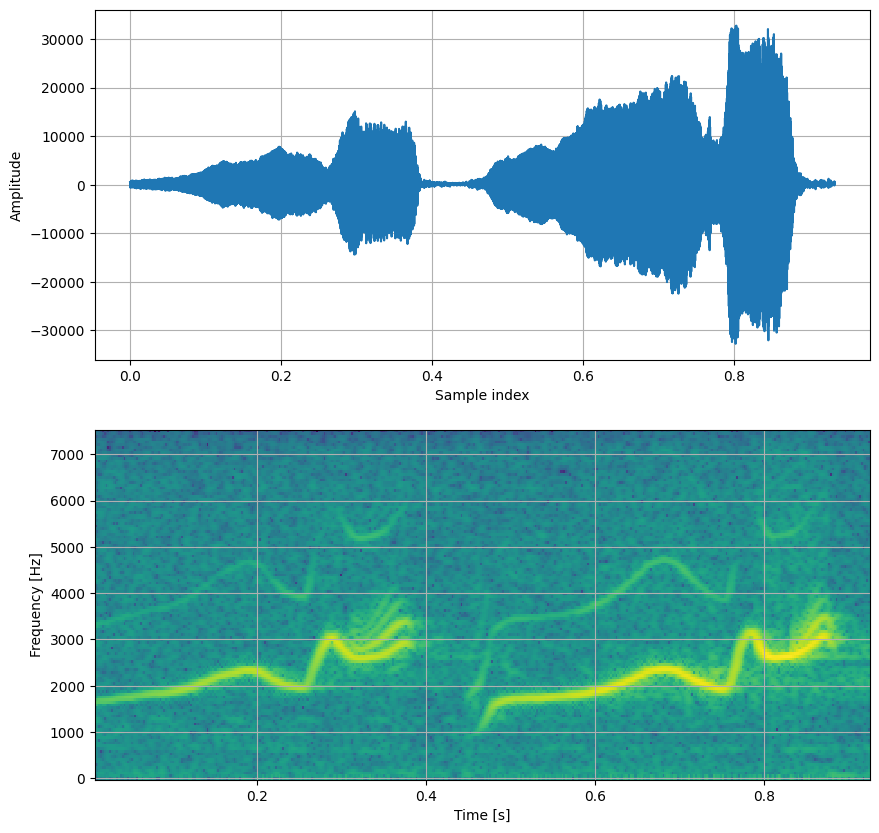

In [35]:
figure(figsize=(10, 10))

t = np.arange(0, y.size) / fs

# The signal in time domain
subplot(211)
plot(t[0:n], y)
ylabel("Amplitude")
xlabel("Sample index")
grid()

# Time frequency representation
# figure(figsize=(12.7,6))
subplot(212)
width = 256  # we usually use a power of 2
spacing = width / 8
f_Sy, t_Sy, Sy = spectrogram(
    y, fs, window="hann", nperseg=width, noverlap=width - spacing
)
ax = pcolormesh(t_Sy, f_Sy, Sy, norm=LogNorm())
ylabel("Frequency [Hz]")
xlabel("Time [s]")
grid()
# colorbar()
show()

### Exercise 4

1. Explain how the horizontal and vertical axes of the spectrogram have been indexed and discretized. How should one read and interpret them?

   **Indication:** *for the frequency axis, consider the number of time samples (number of analyzed segments) represented. For the frequency axis, we have the resolution of the discrete Fourier transform of a discrete signal of length `width` (length of the analysis window), sampled at the frequency $f_s$.*

2. Plot the spectrograms of the `glockenspiel_mono.wav` and `desactive_mono.wav` sounds provided in the `sounds\` folder. Observe and comment.
3. The functions `stft` and `spectrogram` call for an optional parameter `window='hann'`. Play with various windows and compare the resulting spectrograms.

**Online documentation at** https://docs.scipy.org/doc/scipy/reference/signal.html#window-functions

### Answers to Exercise 4

In [36]:
# Axes of the spectrogram computed above (bird, width = 256, spacing = width/8)
print("fs = %d Hz, n = %d samples (%.3f s)" % (fs, y.size, y.size / fs))
print("Frequency axis: %d values from %.1f Hz to %.1f Hz, step fs/width = %.2f Hz"
      % (f_Sy.size, f_Sy[0], f_Sy[-1], f_Sy[1] - f_Sy[0]))
print("Time axis: %d values from %.4f s to %.4f s, step spacing/fs = %.2f ms"
      % (t_Sy.size, t_Sy[0], t_Sy[-1], 1000 * (t_Sy[1] - t_Sy[0])))
print("Each window lasts width/fs = %.1f ms" % (1000 * width / fs))

fs = 15000 Hz, n = 14000 samples (0.933 s)
Frequency axis: 129 values from 0.0 Hz to 7500.0 Hz, step fs/width = 58.59 Hz
Time axis: 430 values from 0.0085 s to 0.9237 s, step spacing/fs = 2.13 ms
Each window lasts width/fs = 17.1 ms


**1.** The spectrogram is a 2D array $S[m, k] = |\mathrm{STFT}\, x(m \cdot \text{spacing}, k)|^2$:

- **Horizontal axis (time).** One column per analysed segment. Successive windows are shifted by `spacing` = `width`/8 = 32 samples, so the column index $m$ corresponds to the time $t_m = (m \cdot \text{spacing} + \text{width}/2)/f_s$ of the **centre** of the window: the time step is $\text{spacing}/f_s$ = 2.13 ms, and the first column is at $\text{width}/(2 f_s)$ = 8.5 ms. For $n$ = 14000 samples this gives 430 columns.
- **Vertical axis (frequency).** One row per coefficient of the discrete Fourier transform of a segment of `width` samples. Only the positive frequencies are kept (the signal is real), so there are $\text{width}/2 + 1$ = 129 rows, from 0 to $f_s/2$ = 7500 Hz, with a step $f_s/\text{width}$ = 58.6 Hz.
- **Colour.** The value at $(t_m, f_k)$ is the energy of the signal around frequency $f_k$ inside the window centred at $t_m$ (log colour scale).

It must be read as a map of energy density in the time-frequency plane, with a resolution limited by the window: nothing finer than about `width`$/f_s$ = 17 ms in time and $f_s/$`width` = 59 Hz in frequency can be resolved, and the 7/8 overlap only makes the image smoother, it does not improve the resolution.

**Question 2.** Spectrograms of `glockenspiel_mono.wav` and `desactive_mono.wav` (hann window, `width` = 256). The whole signals are displayed.

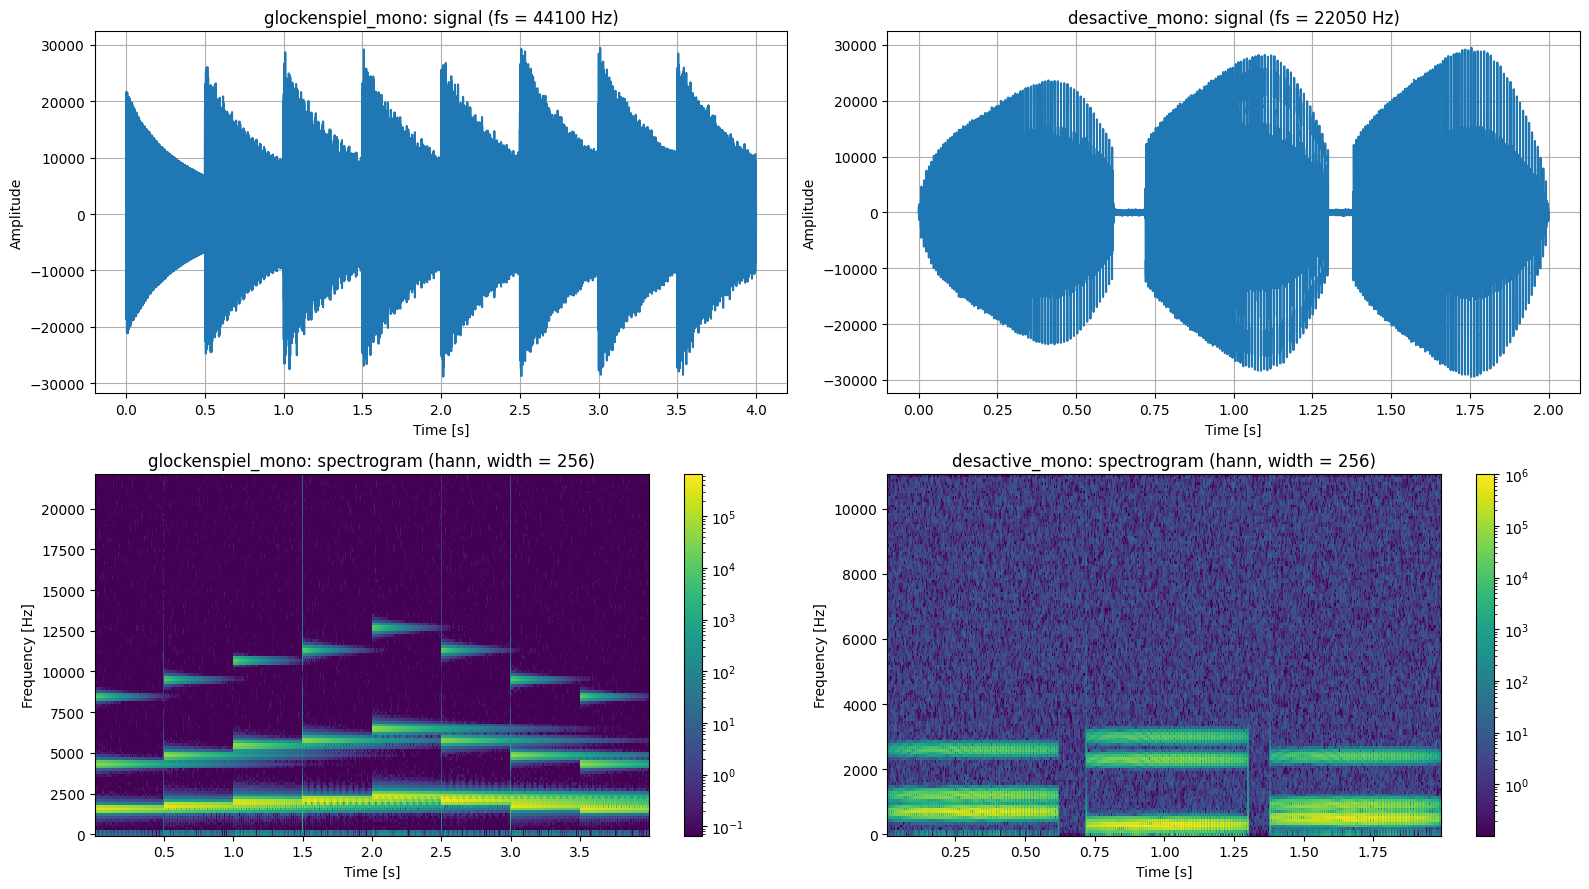

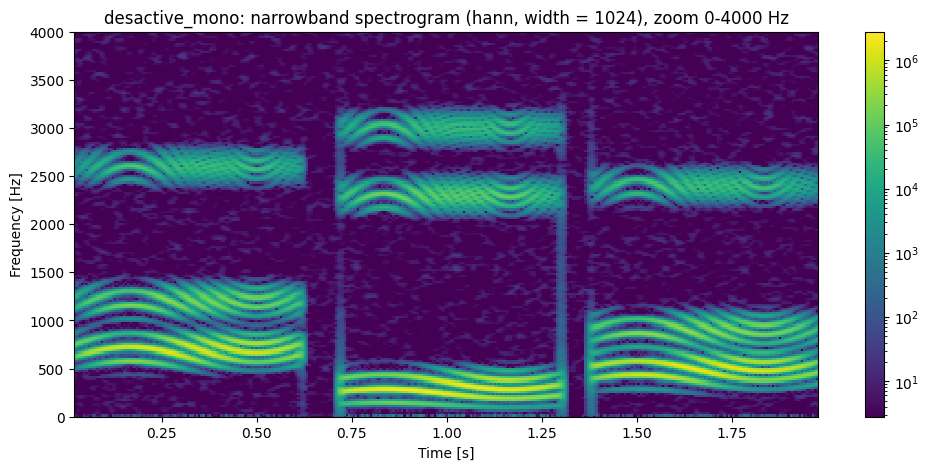

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for col, name in enumerate(["glockenspiel_mono", "desactive_mono"]):
    fs_s, s = read("sounds/" + name + ".wav")
    s = s.astype(float)
    t_s = np.arange(s.size) / fs_s

    axes[0, col].plot(t_s, s)
    axes[0, col].set_title("%s: signal (fs = %d Hz)" % (name, fs_s))
    axes[0, col].set_xlabel("Time [s]")
    axes[0, col].set_ylabel("Amplitude")
    axes[0, col].grid()

    width = 256
    spacing = width // 8
    f_S, t_S, S = spectrogram(s, fs_s, window="hann", nperseg=width, noverlap=width - spacing)
    im = axes[1, col].pcolormesh(t_S, f_S, S + 1e-12 * S.max(), norm=LogNorm(vmin=1e-7 * S.max()), shading="auto")
    axes[1, col].set_title("%s: spectrogram (hann, width = %d)" % (name, width))
    axes[1, col].set_xlabel("Time [s]")
    axes[1, col].set_ylabel("Frequency [Hz]")
    fig.colorbar(im, ax=axes[1, col])
tight_layout()
show()

# narrowband spectrogram of the voice: a longer window resolves the harmonics
fs_s, s = read("sounds/desactive_mono.wav")
width = 1024
f_S, t_S, S = spectrogram(s.astype(float), fs_s, window="hann", nperseg=width, noverlap=width - width // 8)
figure(figsize=(12, 5))
pcolormesh(t_S, f_S, S + 1e-12 * S.max(), norm=LogNorm(vmin=1e-6 * S.max()), shading="auto")
ylim(0, 4000)
xlabel("Time [s]")
ylabel("Frequency [Hz]")
title("desactive_mono: narrowband spectrogram (hann, width = 1024), zoom 0-4000 Hz")
colorbar()
show()

**Glockenspiel** ($f_s$ = 44100 Hz). Eight notes are struck every 0.5 s. In the time domain, each note is an abrupt attack followed by an exponential decay. On the spectrogram, each attack is a thin **vertical line** (an impulse spreads energy over all frequencies), followed by **horizontal lines** (stationary partials) that fade out. For each note, three lines are visible: the fundamental, which carries the melody (about 1600 Hz, rising to 2350 Hz at $t$ = 2 s and coming back to 1600 Hz), and two weaker partials at about **2.76 and 5.4 times** the fundamental (4300 to 6500 Hz and 8500 to 12700 Hz). These ratios are not integers: the partials of a metal bar are **inharmonic**, which gives the metallic timbre. The higher the partial, the faster it decays (its line is shorter), and the fundamental of a note is still ringing when the next note is struck, so several notes overlap.

**"Désactivé" (synthetic voice,** $f_s$ = 22050 Hz). The signal is made of three syllables separated by two short silences (about 0.62 to 0.72 s and 1.30 to 1.38 s, dark vertical bands). With `width` = 256 (11.6 ms), each syllable appears as a few **horizontal energy bands**, the *formants*, which change from one syllable to the next: around 700, 1200 and 2600 Hz for the first one, 300, 2300 and 3000 Hz for the second, 500, 900 and 2400 Hz for the third. These resonances define the vowels. Inside the bands, fine vertical striations can be seen: the window is shorter than a few periods of the fundamental, so it resolves the individual glottal pulses in time rather than the harmonics in frequency (*wideband* spectrogram). With a longer window (`width` = 1024, 46 ms, second figure), the frequency resolution becomes 21.5 Hz and the **harmonics** of the fundamental appear as a comb of parallel lines, spaced by about 100 to 145 Hz and bending together as the pitch varies (intonation); the formants are then the zones where these harmonics are reinforced (*narrowband* spectrogram).

In both cases, the spectrogram shows what neither the time signal (only the envelope is visible) nor the global spectrum (no time information) can show: which frequencies are present, and when.

**Question 3.** Influence of the analysis window (`width` = 256 for all), on the bird song and on the glockenspiel.

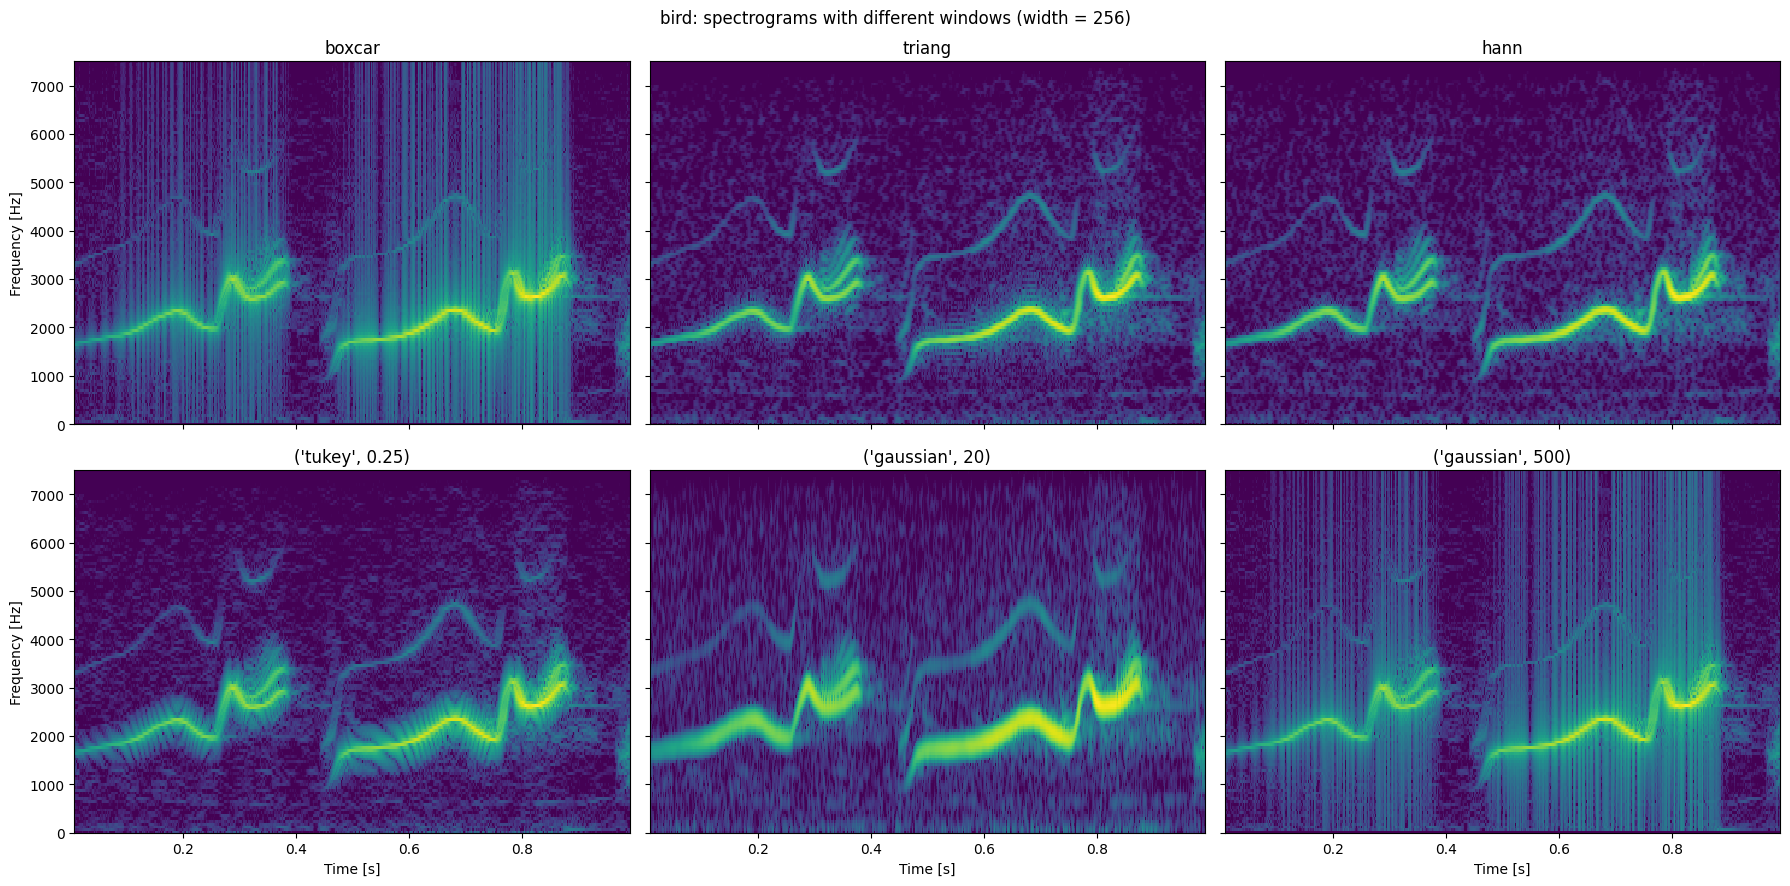

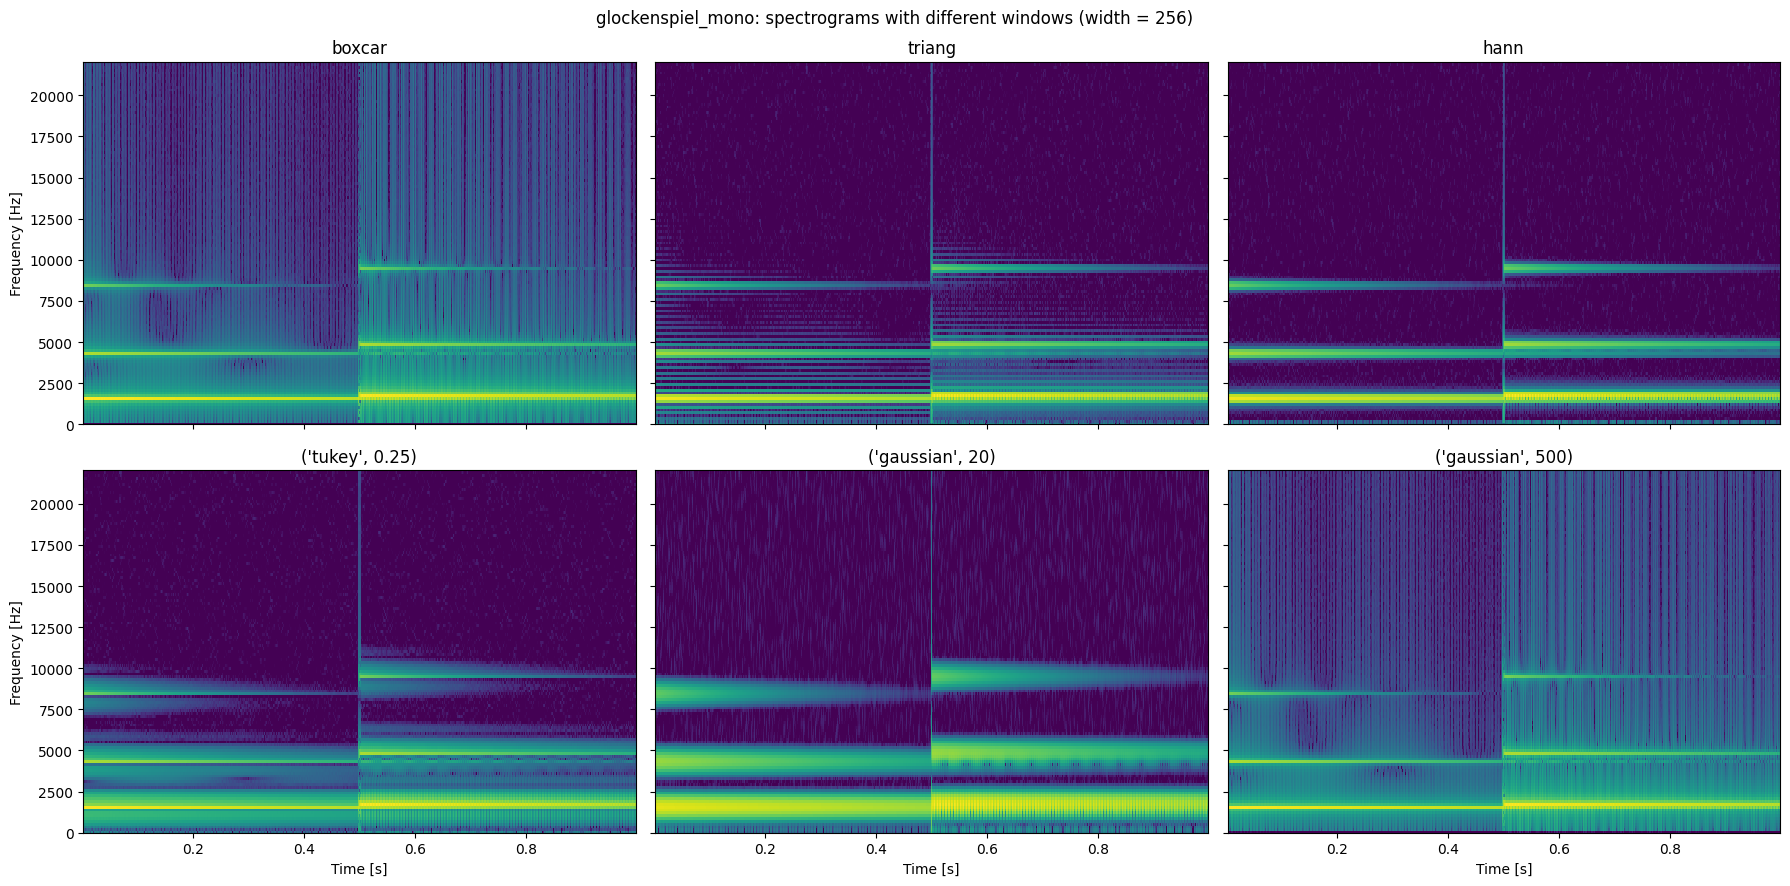

In [38]:
windows = ["boxcar", "triang", "hann", ("tukey", 0.25), ("gaussian", 20), ("gaussian", 500)]
width = 256
spacing = width // 8

for name in ["bird", "glockenspiel_mono"]:
    fs_s, s = read("sounds/" + name + ".wav")
    s = s.astype(float)[: int(1.0 * fs_s)]  # first second of the signal
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True, sharey=True)
    for ax, window_type in zip(axes.ravel(), windows):
        f_S, t_S, S = spectrogram(s, fs_s, window=window_type, nperseg=width, noverlap=width - spacing)
        ax.pcolormesh(t_S, f_S, S + 1e-12 * S.max(), norm=LogNorm(vmin=1e-7 * S.max()), shading="auto")
        ax.set_title(str(window_type))
        ax.set_ylim(0, fs_s / 2)
    for ax in axes[1]:
        ax.set_xlabel("Time [s]")
    for ax in axes[:, 0]:
        ax.set_ylabel("Frequency [Hz]")
    fig.suptitle("%s: spectrograms with different windows (width = %d)" % (name, width))
    tight_layout()
    show()

All the spectrograms have the same number of samples per window, but the shape of the window changes the way each spectral line is "smeared" in frequency:

- **`boxcar` (rectangular)**: the thinnest main lobe, but high side lobes (-13 dB). Each strong line leaks energy over the whole frequency axis: bright **vertical stripes** covering all frequencies appear wherever the signal is loud, and weak components (the second harmonic of the bird near 5000 Hz, the high partials of the glockenspiel) are partly hidden.
- **`('gaussian', 500)`**: a standard deviation of 500 samples for a window of 256 samples is almost flat, so it behaves like the rectangular window, with the same leakage.
- **`triang`, `hann`, `('tukey', 0.25)`**: these windows go smoothly to zero at the edges. The side lobes are much lower (-27 dB for `triang`, -31 dB for `hann`), the lines stand out on a dark background and the weak harmonic of the bird is clearly visible, at the price of a slightly wider main lobe. The Tukey window with $\alpha$ = 0.25 is flat over 75 % of its length and is an intermediate case: less leakage than `boxcar`, but ripples are still visible around the strongest lines.
- **`('gaussian', 20)`**: the effective duration is only about 80 samples (5 ms). Time localisation is excellent (the attacks of the glockenspiel become very sharp vertical lines), but the lines are very wide in frequency (about 280 Hz), so that the song looks like a thick ribbon and the close components at the end of each phrase (near 3000 Hz) are no longer separated.

The choice of the window is thus a compromise between **spectral leakage** (dynamic range, visibility of weak components) and **resolution** (time and frequency widths of each atom); a smooth window of the `hann` type is a good default choice.

## Section 4: Analysis of some signals

### Exercise 5

Consider the signal `x` stored in the `signal_2sinus.mat` loaded below, sampled at $f_{s}= 4096$.

1. Study this signal and his spectrogram with a window of your choice. To this aim, you may observe the spectrogram for different windows and widths, for instance `width=64`, `128, 256, 512, 1024`. Which choice of window and width allows the 2 frequencies present in this signal to be properly distinguished? (justify)
2. What is the content of this signal ? Try to be as precise as possible in your description, including characteristic frequencies. Comment and explain these results.

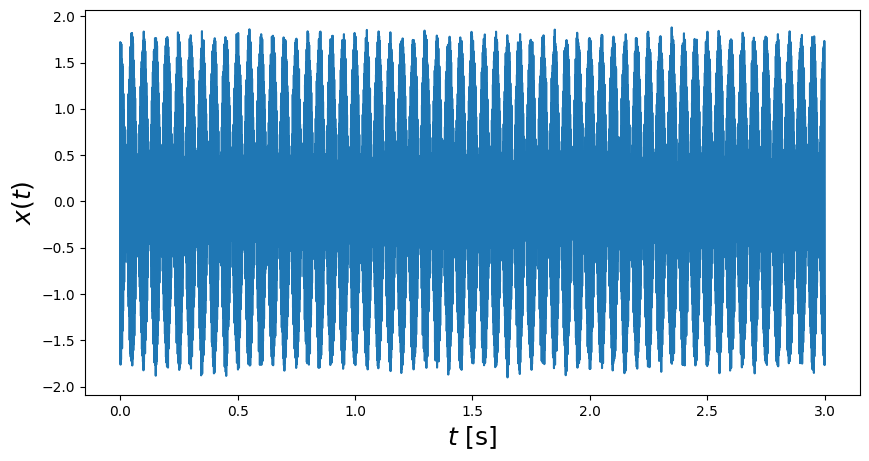

In [39]:
# Load signal x
data = loadmat(
    "signal_2sinus.mat"
)  # load the signal x and the list of sampling time instants (sampling frequency)

t = data["t"][0]
x = data["x"][0]
fs = int(data["Fe"][0][0])  # Python integer, as expected by sounddevice

figure(figsize=(10, 5))
plot(t, x)
xlabel(r"$t$ [s]", fontsize=18)
ylabel(r"$x(t)$", fontsize=18)
show()

# Listen
display(Audio(x, rate=fs))

### Answers to Exercise 5

**Question 1.** Spectrograms for several windows and widths, zoomed on the frequency band that contains the signal. For each width, the time-averaged spectrum is also plotted to check whether two distinct peaks appear.

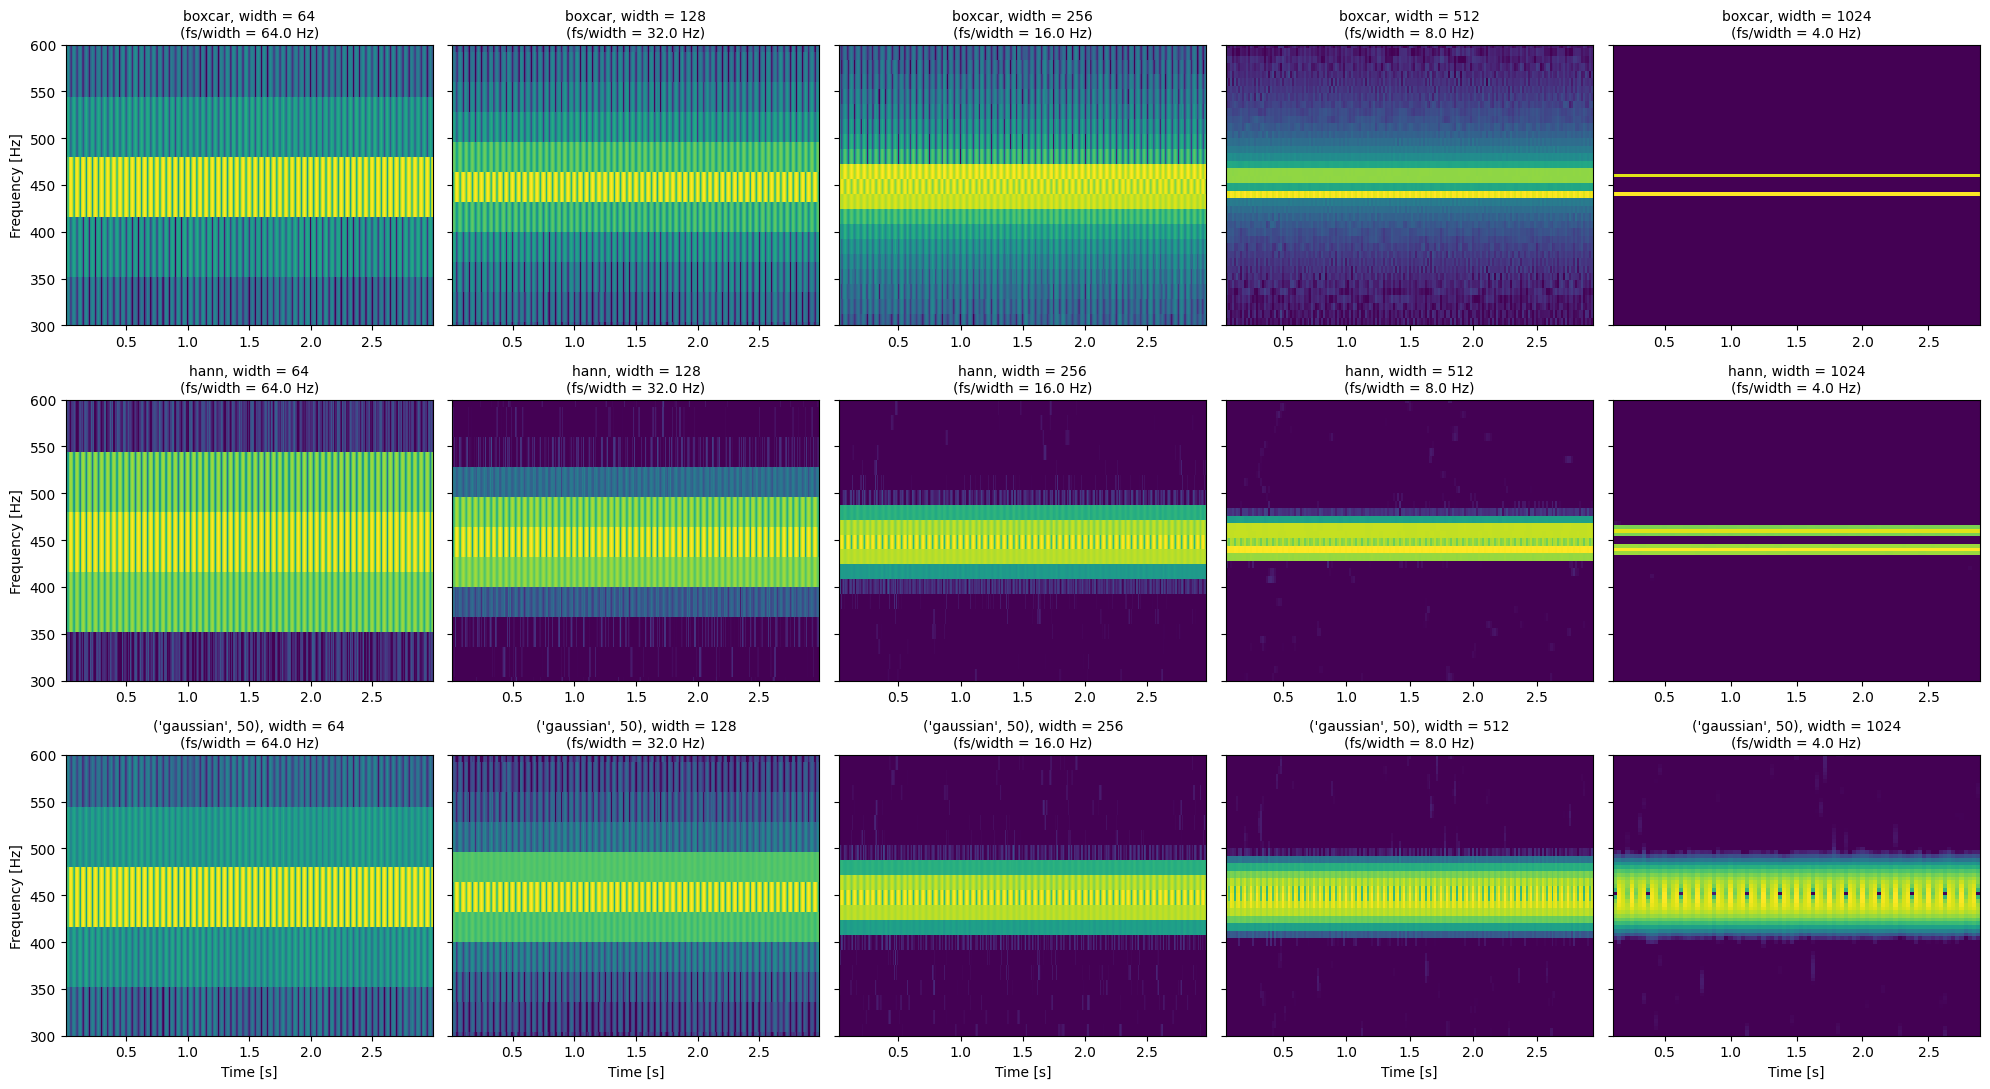

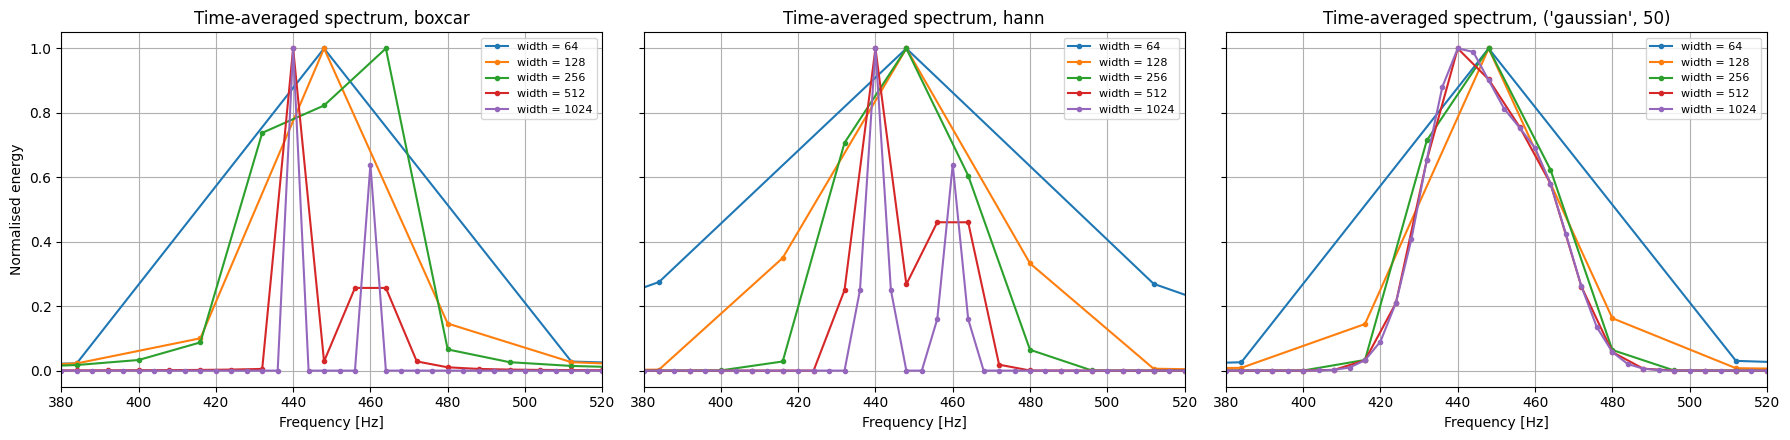

In [40]:
widths = [64, 128, 256, 512, 1024]
windows = ["boxcar", "hann", ("gaussian", 50)]

fig, axes = plt.subplots(len(windows), len(widths), figsize=(20, 11), sharey=True)
for r, window_type in enumerate(windows):
    for c, width in enumerate(widths):
        spacing = width // 8
        f_S, t_S, S = spectrogram(x, fs, window=window_type, nperseg=width, noverlap=width - spacing)
        ax = axes[r, c]
        ax.pcolormesh(t_S, f_S, S + 1e-12 * S.max(), norm=LogNorm(vmin=1e-4 * S.max()), shading="auto")
        ax.set_ylim(300, 600)
        ax.set_title("%s, width = %d\n(fs/width = %.1f Hz)" % (window_type, width, fs / width), fontsize=10)
        if r == len(windows) - 1:
            ax.set_xlabel("Time [s]")
        if c == 0:
            ax.set_ylabel("Frequency [Hz]")
tight_layout()
show()

fig, axes = plt.subplots(1, len(windows), figsize=(18, 4.5), sharey=True)
for ax, window_type in zip(axes, windows):
    for width in widths:
        f_S, t_S, S = spectrogram(x, fs, window=window_type, nperseg=width, noverlap=width - width // 8)
        mean_S = S.mean(axis=1)
        ax.plot(f_S, mean_S / mean_S.max(), ".-", label="width = %d" % width)
    ax.set_xlim(380, 520)
    ax.set_title("Time-averaged spectrum, %s" % str(window_type))
    ax.set_xlabel("Frequency [Hz]")
    ax.grid()
    ax.legend(fontsize=8)
axes[0].set_ylabel("Normalised energy")
tight_layout()
show()

The signal contains two frequencies only **20 Hz** apart (question 2). Two related quantities must be distinguished:

1. the frequency-grid spacing $f_s/\text{width}$ must be fine enough to sample two distinct peaks. It is 64, 32, 16, 8 and 4 Hz for `width` = 64, 128, 256, 512 and 1024, respectively. Thus `width` = 64 and 128 are immediately too short; `width` = 256 gives only about 1.25 bins across the 20 Hz gap and is still too coarse in practice;
2. more importantly, the **main lobe** of the window must be narrower than the gap: approximately $2 f_s/\text{width}$ for the rectangular window and $4 f_s/\text{width}$ for the Hann window, i.e. 16 Hz and 32 Hz for `width` = 512, and 8 Hz and 16 Hz for `width` = 1024.

This is confirmed by the figures. With `width` $\leq$ 256, a single wide line centred near 450 Hz is visible for all windows (the vertical striations seen with short windows are the beats of question 2, which a short window follows in time). With `width` = 512, the rectangular window already separates the two lines (two peaks with a deep dip between them, main lobe 16 Hz), whereas with `hann` (main lobe 32 Hz) the two peaks overlap. With **`width` = 1024**, both `boxcar` and `hann` give two thin, well-separated lines at 440 and 460 Hz. With `('gaussian', 50)` the effective window only lasts about 200 samples whatever `width`, so its main lobe stays about 30 Hz wide and the lines are **never** separated.

For `width` = 1024, 440 and 460 Hz are both exact multiples of the 4 Hz grid spacing, so the rectangular-window samples happen to fall on the zeros of the neighbouring sinc lobes and leakage is barely visible. This exact alignment does **not** hold for `width` = 512 (the spacing is 8 Hz and 460 Hz lies between two bins), nor would it hold for arbitrary frequencies. Away from the DFT grid, a rectangular window produces much stronger leakage than a Hann window.

The best choice is therefore a long, smooth window: **`hann` with `width` = 1024** (0.25 s). Since the signal is stationary, nothing is lost by using a long window: poor time resolution is not a problem here, whereas frequency resolution is essential.

**Question 2.** Precise description of the content of the signal.

Peak at 440.00 Hz, amplitude 1.00
Peak at 460.00 Hz, amplitude 0.80
Amplitudes from the fit: [1.  0.8]
Standard deviation of the residual (noise): 0.050


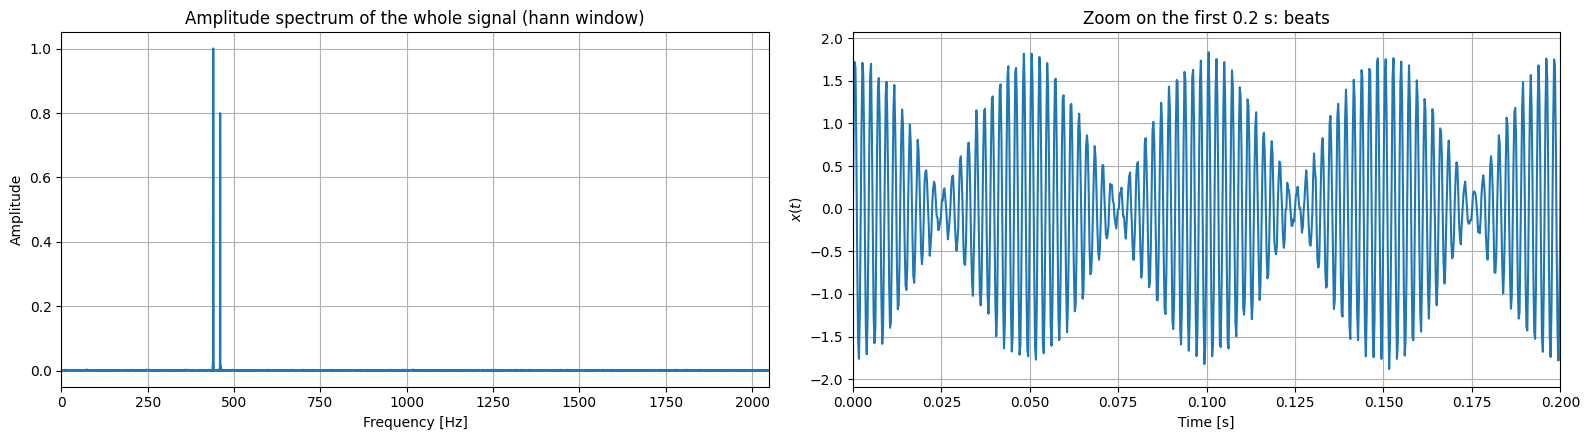

In [41]:
nfft = 2 ** 16
hann_full = get_window("hann", x.size)
X_full = np.abs(np.fft.rfft(x * hann_full, nfft)) / (hann_full.sum() / 2)  # amplitude of each sinusoid
f_full = np.fft.rfftfreq(nfft, d=1.0 / fs)
peaks, _ = find_peaks(X_full, height=0.1 * X_full.max())
for p in peaks:
    print("Peak at %.2f Hz, amplitude %.2f" % (f_full[p], X_full[p]))

# least-squares fit of the two sinusoids, the residual gives the noise level
M = np.column_stack([f(2 * np.pi * f_full[p] * t) for p in peaks for f in (np.cos, np.sin)])
coef, *_ = np.linalg.lstsq(M, x, rcond=None)
residual = x - M @ coef
print("Amplitudes from the fit:", np.round(np.hypot(coef[0::2], coef[1::2]), 3))
print("Standard deviation of the residual (noise): %.3f" % residual.std())

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].plot(f_full, X_full)
axes[0].set_xlim(0, fs / 2)
axes[0].set_title("Amplitude spectrum of the whole signal (hann window)")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("Amplitude")
axes[0].grid()
axes[1].plot(t, x)
axes[1].set_xlim(0, 0.2)
axes[1].set_title("Zoom on the first 0.2 s: beats")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel(r"$x(t)$")
axes[1].grid()
tight_layout()
show()

The signal lasts 3 s ($f_s$ = 4096 Hz) and is **stationary**: the spectrogram shows two horizontal lines that do not change over time. It is the sum of **two sinusoids** of constant frequencies and amplitudes, plus a weak background noise:

- $f_1 \approx$ **440 Hz** with an amplitude close to **1**;
- $f_2 \approx$ **460 Hz** with an amplitude close to **0.8**;
- a weak wideband white noise (flat floor over the whole spectrum, standard deviation of order 0.05).

In the time domain, the two close frequencies produce **beats**: $\cos(2\pi f_1 t) + \cos(2\pi f_2 t) = 2\cos(\pi (f_2 - f_1) t)\cos(\pi (f_1 + f_2) t)$, so the signal oscillates at the mean frequency 450 Hz with an envelope that varies periodically, with a period $1/(f_2 - f_1)$ = 50 ms (visible on the zoom). Since the amplitudes are different, the envelope oscillates between $1 + 0.8 = 1.8$ and $1 - 0.8 = 0.2$ instead of reaching zero. This is why a short window sees a single sinusoid at 450 Hz whose amplitude varies in time (it resolves the beats but not the two frequencies), whereas a long window resolves the two frequencies but averages the beats: two descriptions of the same signal, at two different time-frequency resolutions.

### Time-frequency analysis of hyperbolic chirps

In this section, we consider the superposition of 2 "chirps", *i.e.*, signals whose frequency varies continuously, in a hyperbolic way (see the help of the `chirp` function in Python). As a result, we face a resolution problem, since the width of the window is constant for the entire signal, and may thus not be suitable for all the time instants.

The ultrasonic cries produced by bats typically have a similar structure, as well as gravitational waves observed in astrophysics.

In [42]:
# chirp(t, f0, t1, f1[, method, phi, vertex_zero]) Frequency-swept cos
fs = 4096
T = 3
f1_min, f1_max = 200, 1600
f2_min, f2_max = 250, 1650

t = linspace(0, 3, fs * T)
y1 = chirp(t, f1_min, T, f2_max, method="hyperbolic")
y2 = chirp(t, f2_min, T, f2_max, method="hyperbolic")
y = y1 + y2

display(Audio(y, rate=fs))  # let's play the sound

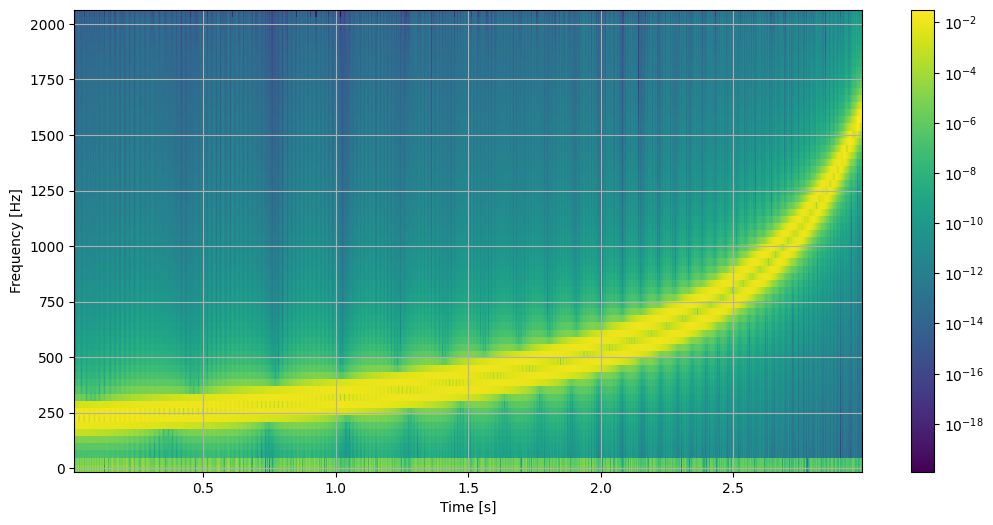

In [43]:
width = 128
window = get_window("hann", width)

figure(figsize=(12.7, 6))
f_Sy, t_Sy, Sy = spectrogram(
    y, fs=fs, window=window, nperseg=width, noverlap=7 * width / 8
)
pcolormesh(
    t_Sy, f_Sy, Sy, norm=LogNorm()
)  # the top of the spectrogram corresponds to the high frequencies
ylabel("Frequency [Hz]")
xlabel("Time [s]")
grid()
colorbar()
show()

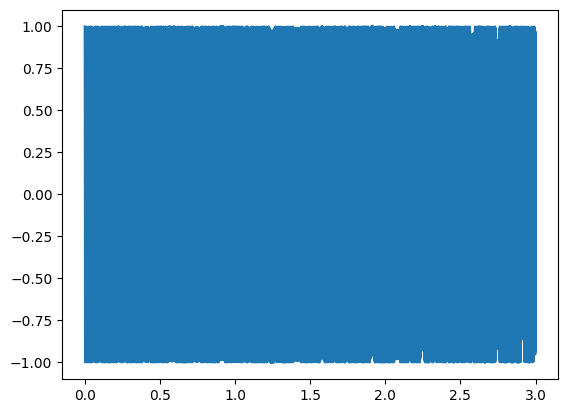

In [44]:
plot(t, y1)
show()

### Exercise 6

1. Observe the results obtained by the above analysis. What is the nature of this signal?
2. Observe the quality of the spectrogram using different windows. Modify the width of the window, and highlight situations where the spectrogram allows or doesn't allow the different components of the signal to be distinguished.

### Answers to Exercise 6

t = 0.0 s: f1 =  200.0 Hz, f2 =  250.0 Hz, gap =  50.0 Hz
t = 1.0 s: f1 =  282.9 Hz, f2 =  348.6 Hz, gap =  65.7 Hz
t = 2.0 s: f1 =  483.0 Hz, f2 =  575.6 Hz, gap =  92.7 Hz
t = 2.5 s: f1 =  747.3 Hz, f2 =  853.6 Hz, gap = 106.3 Hz
t = 3.0 s: f1 = 1650.0 Hz, f2 = 1650.0 Hz, gap =   0.0 Hz


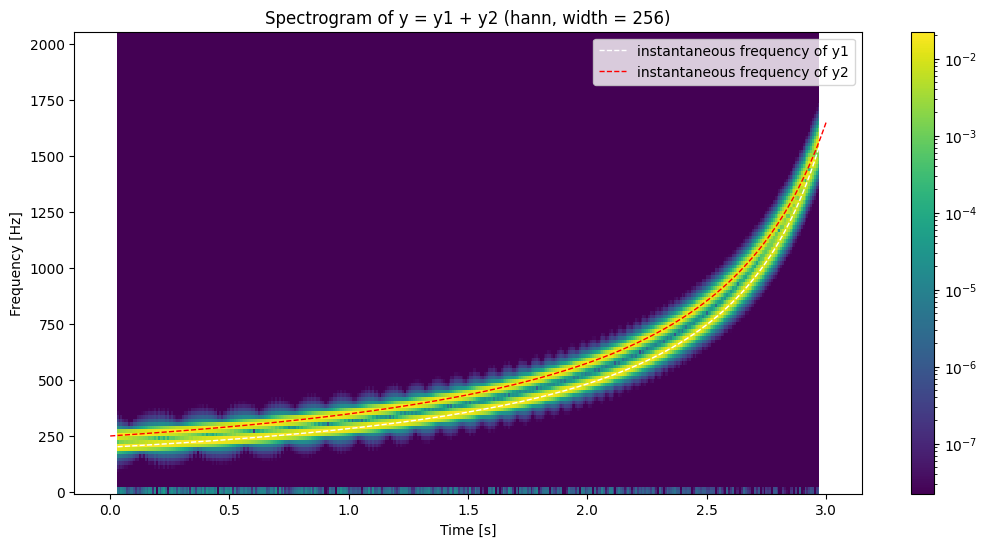

In [45]:
# Instantaneous frequencies of the two chirps generated above
def hyperbolic_frequency(t, f0, t1, f1):
    # instantaneous frequency of scipy.signal.chirp with method='hyperbolic'
    return f0 * f1 * t1 / ((f0 - f1) * t + f1 * t1)

f_inst1 = hyperbolic_frequency(t, f1_min, T, f2_max)  # y1 goes from f1_min to f2_max (see the cell above)
f_inst2 = hyperbolic_frequency(t, f2_min, T, f2_max)
for tt in [0, 1, 2, 2.5, 3]:
    i = min(int(tt * fs), t.size - 1)
    print("t = %.1f s: f1 = %6.1f Hz, f2 = %6.1f Hz, gap = %5.1f Hz" % (tt, f_inst1[i], f_inst2[i], f_inst2[i] - f_inst1[i]))

width = 256
f_Sy, t_Sy, Sy = spectrogram(y, fs=fs, window="hann", nperseg=width, noverlap=7 * width // 8)
figure(figsize=(12.7, 6))
pcolormesh(t_Sy, f_Sy, Sy, norm=LogNorm(vmin=1e-6 * Sy.max()), shading="auto")
plot(t, f_inst1, "w--", linewidth=1, label="instantaneous frequency of y1")
plot(t, f_inst2, "r--", linewidth=1, label="instantaneous frequency of y2")
ylabel("Frequency [Hz]")
xlabel("Time [s]")
title("Spectrogram of y = y1 + y2 (hann, width = 256)")
legend()
colorbar()
show()

**1.** The signal is the sum of two **hyperbolic chirps**, i.e. sinusoids of constant amplitude whose frequency increases continuously with time following $f(t) = \dfrac{f_0 f_1 T}{(f_0 - f_1)t + f_1 T}$ (dashed curves, which match the spectrogram). Note that, in the code above, both chirps end at `f2_max` = 1650 Hz: $y_1$ goes from 200 Hz to 1650 Hz and $y_2$ from 250 Hz to 1650 Hz in $T$ = 3 s. The frequency increases slowly at the beginning (about 280 and 350 Hz at $t$ = 1 s) and faster and faster at the end (the curves bend upwards). The gap between the two components is 50 Hz at $t$ = 0, grows to a maximum of about **106 Hz at $t$ = 2.5 s**, then shrinks quickly to **0 Hz at $t$ = 3 s**, where both chirps reach the same frequency. The small bubbles along the lines at the beginning are interferences (beats) between the two close components inside each window.

**Question 2.** Spectrograms for several windows and widths.

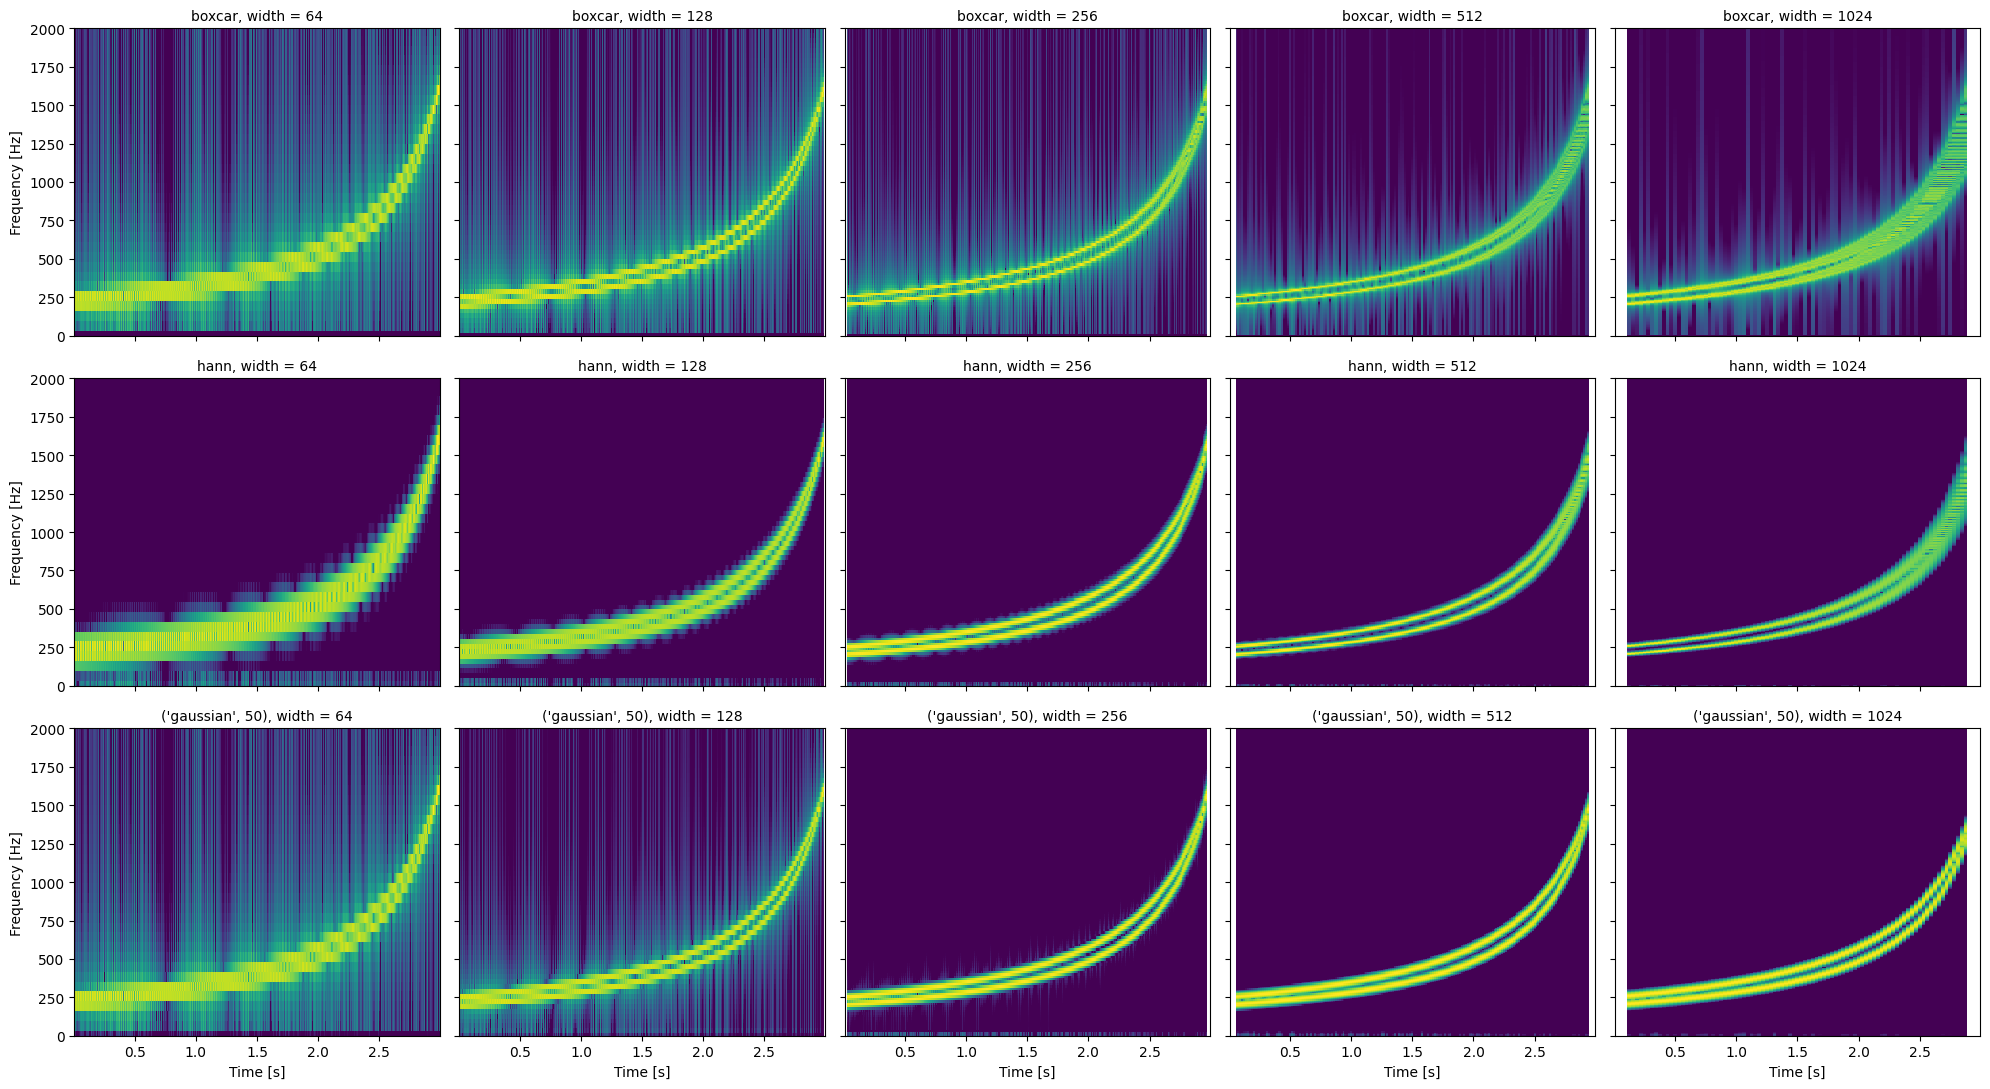

In [46]:
widths = [64, 128, 256, 512, 1024]
windows = ["boxcar", "hann", ("gaussian", 50)]

fig, axes = plt.subplots(len(windows), len(widths), figsize=(20, 11), sharex=True, sharey=True)
for r, window_type in enumerate(windows):
    for c, width in enumerate(widths):
        f_S, t_S, S = spectrogram(y, fs=fs, window=window_type, nperseg=width, noverlap=7 * width // 8)
        ax = axes[r, c]
        ax.pcolormesh(t_S, f_S, S + 1e-12 * S.max(), norm=LogNorm(vmin=1e-5 * S.max()), shading="auto")
        ax.set_ylim(0, 2000)
        ax.set_title("%s, width = %d" % (window_type, width), fontsize=10)
        if r == len(windows) - 1:
            ax.set_xlabel("Time [s]")
        if c == 0:
            ax.set_ylabel("Frequency [Hz]")
tight_layout()
show()

Two resolutions are in competition, and no single window is good everywhere:

- **Short windows** (`width` = 64, 16 ms, frequency step 64 Hz): the fast final sweep is well followed in time, but the two components, 50 to 106 Hz apart, fall into the same one or two frequency bins: only **one thick staircase-like curve** is visible over the whole signal.
- **`width` = 128** (step 32 Hz): the two lines start to separate after about 1.5 s, when their gap exceeds 70 Hz, but are merged at the beginning.
- **`width` = 256 and 512 with `hann`**: the two chirps are **clearly separated** from the beginning up to about 2.8 s; this is the best compromise.
- **`width` = 1024** (0.25 s): the lines are very thin at the beginning, where the frequencies vary slowly, but at the end the frequency increases by several hundred Hz during a single window, so each line is **smeared vertically** and the two components merge into a wide band after about 2.5 s.
- **Window shape**: `boxcar` adds strong leakage (vertical stripes over the whole band, especially for long windows) which hides the separation; `hann` gives the cleanest images. `('gaussian', 50)` has an effective duration of about 200 samples whatever `width`: for `width` $\geq$ 256 it behaves like a medium window (main lobe about 30 Hz, enough to separate lines 50 Hz apart, with good time localisation), while for `width` = 64 and 128 it is truncated and behaves almost like a rectangular window.

Near $t$ = 3 s, however, no window can separate the two chirps, since their frequencies become equal. Since the right resolution depends on the rate of change of the frequency, a constant window width is necessarily a compromise for such signals; this motivates representations with an adaptive resolution, such as the wavelet transform (lab 2).